In [1]:
import pandas as pd

df = pd.read_csv('../tack_smiles_split.analysis.csv', low_memory=False)
source_df = pd.read_csv('../tack_smiles.csv')
df = pd.merge(df, source_df, how='left', on='SMILES')
df

,SMILES,default_pred_n0,model_name,heuristic_params,protac_heavy_atoms,protac_mw,protac_graph_diameter,protac_num_bonds,protac_num_rotatable_bonds,protac_frac_rotatable_bonds,...,reason_leaving_group,reason_linker_branchy,reason_linker_too_short,reason_low_confidence,reason_method_disagreement,reason_poi_linker_leak,reason_poi_low_similarity,reason_poi_out_of_range,reason_unstable,Database
0,CCC(C)(C)C(=O)C(=O)N1CCCC[C@H]1C(=O)O[C@H](CCc...,O=C(CCl)[*:2].O=C(CO[*:1])NCCCOCCOCCOCCCN(C(C(...,XGBoost,NaN,79,1154.6,38,83,34,0.430,...,True,True,False,True,True,False,False,False,True,PROTAC-DB
1,O=C(COc1ccc2c(c1)CCCN2C(=O)CCl)NCCOCCOCCOCCOCC...,O=C(CCl)N1CCCc2cc([*:2])ccc21.O=C(CO[*:2])NCCO...,Heuristic,"betweenness_threshold=0.3,use_capacity_weight=...",82,1205.6,50,88,32,0.390,...,True,True,False,True,True,False,True,False,True,TPDdb
2,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OCC(=O)NCCCCCCNC(...,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OCC(=O)[*:2].CC(C...,Heuristic,"betweenness_threshold=0.5,use_capacity_weight=...",63,889.1,32,64,20,0.317,...,True,True,False,True,False,False,True,True,True,TPDdb
3,C=C(CC)C(=O)c1ccc(OCC(=O)NCCCCCCCC(=O)C(CCCN/C...,C=C(CC)C(=O)c1ccc([*:2])c(Cl)c1Cl.CC(C)(C)OC(=...,Heuristic,"betweenness_threshold=0.5,use_capacity_weight=...",58,856.9,30,58,20,0.345,...,True,True,False,True,False,False,True,True,True,TPDdb
4,O=C(CCOCCOCCOCCOCCOCCOCCC(=O)NCCCOc1cccc2c1C(=...,O=C1CCC(N2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1.O=C...,XGBoost,NaN,68,1020.3,48,71,34,0.500,...,True,True,False,True,True,False,True,False,True,PROTAC-DB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24807,CC(C)c1cnn2c(NCc3ccc(NC(=O)CCCCCCCOc4cccc5c4C(...,O=C1CCC(N2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1.O=C...,Heuristic,"betweenness_threshold=0.4,use_capacity_weight=...",63,860.0,33,70,18,0.286,...,False,False,False,False,False,False,False,False,False,TPDdb
24808,CC(C)c1cnn2c(NCc3ccc(NC(=O)CCCCCCCOc4cccc5c4C(...,O=C1CCC(N2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1.O=C...,Heuristic,"betweenness_threshold=0.4,use_capacity_weight=...",58,794.9,33,64,17,0.293,...,False,False,False,False,False,False,False,False,False,TPDdb
24809,CC(C)c1cnn2c(NCc3ccc(NC(=O)CCCCCCc4cccc5c4CN(C...,O=C1CCC(N2Cc3c(cccc3[*:2])C2=O)C(=O)N1.O=C(CCC...,Heuristic,"betweenness_threshold=0.4,use_capacity_weight=...",55,747.9,31,61,15,0.273,...,False,False,False,False,False,False,False,False,False,TPDdb
24810,CC(C)c1cnn2c(NCc3ccc(NC(=O)CCCCCN4CCN(CCCCc5cc...,O=C1CCC(N2Cc3c(cccc3[*:2])C2=O)C(=O)N1.O=C(CCC...,Heuristic,"betweenness_threshold=0.4,use_capacity_weight=...",64,876.1,38,71,19,0.297,...,False,False,False,False,False,False,False,False,False,TPDdb


In [ ]:
metrics = {
    'protac': [c for c in df.columns if c.startswith('protac')],
    'e3': [c for c in df.columns if c.startswith('e3')],
    'linker': [c for c in df.columns if c.startswith('linker')],
    'poi': [c for c in df.columns if c.startswith('poi')],
}
metrics

{'protac': ['protac_heavy_atoms',
  'protac_mw',
  'protac_graph_diameter',
  'protac_num_bonds',
  'protac_num_rotatable_bonds',
  'protac_frac_rotatable_bonds',
  'protac_rotatable_bond_ratio',
  'protac_frac_csp3',
  'protac_tpsa',
  'protac_logp',
  'protac_num_stereocenters',
  'protac_num_rings',
  'protac_num_aromatic_rings',
  'protac_num_aliphatic_rings',
  'protac_num_saturated_rings',
  'protac_max_ring_size',
  'protac_num_macrocycles',
  'protac_num_spiro_atoms',
  'protac_num_bridgehead_atoms',
  'protac_num_brenk_hits',
  'protac_ring_sizes',
  'protac_macrocycle_sizes',
  'protac_rare_elements',
  'protac_brenk_hits',
  'protac_flag_rare_element'],
 'e3': ['e3_heavy_atoms',
  'e3_mw',
  'e3_graph_diameter',
  'e3_num_bonds',
  'e3_num_rotatable_bonds',
  'e3_frac_rotatable_bonds',
  'e3_rotatable_bond_ratio',
  'e3_frac_csp3',
  'e3_tpsa',
  'e3_logp',
  'e3_num_stereocenters',
  'e3_num_rings',
  'e3_num_aromatic_rings',
  'e3_num_aliphatic_rings',
  'e3_num_saturated_

## Distribution overview & outlier / quality-control analysis

Goal: isolate the "best quality" PROTAC molecules and flag rows that look like bad SMILES parsing, weird chemistry, or non-PROTAC molecules entirely (expected to be a minority). Rather than one giant grid of boxplots across all ~160 columns, this uses small-multiple histograms (boxplots hide multimodality and are more useful for *group comparisons*, used later), plus a combination of a rule-based check and four IsolationForest pipelines over PROTAC-only, linker-only, PROTAC+linker, and all-fragment feature sets.

In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

def numeric_feature_columns(prefix, df):
    """Numeric, non-boolean, non-constant columns for a given substructure prefix."""
    cols = [c for c in df.columns if c.startswith(prefix)]
    cols = [c for c in cols if pd.api.types.is_numeric_dtype(df[c]) and not pd.api.types.is_bool_dtype(df[c])]
    cols = [c for c in cols if df[c].nunique(dropna=True) > 1]
    return cols

def drop_correlated(cols, df, threshold=0.98):
    """Greedily drop one of each pair of near-duplicate features (e.g. mw vs heavy_atoms)."""
    if len(cols) < 2:
        return cols
    corr = df[cols].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if (upper[c] > threshold).any()]
    return [c for c in cols if c not in to_drop]

feature_groups = {
    'protac': numeric_feature_columns('protac_', df),
    'e3': numeric_feature_columns('e3_', df),
    'linker': numeric_feature_columns('linker_', df),
    'poi': numeric_feature_columns('poi_', df),
}
feature_groups = {k: drop_correlated(v, df) for k, v in feature_groups.items()}

for k, v in feature_groups.items():
    print(f"{k:8s} ({len(v):2d} numeric features): {v}")

protac   (17 numeric features): ['protac_heavy_atoms', 'protac_graph_diameter', 'protac_num_rotatable_bonds', 'protac_frac_rotatable_bonds', 'protac_frac_csp3', 'protac_tpsa', 'protac_logp', 'protac_num_stereocenters', 'protac_num_rings', 'protac_num_aromatic_rings', 'protac_num_aliphatic_rings', 'protac_num_saturated_rings', 'protac_max_ring_size', 'protac_num_macrocycles', 'protac_num_spiro_atoms', 'protac_num_bridgehead_atoms', 'protac_num_brenk_hits']
e3       (19 numeric features): ['e3_heavy_atoms', 'e3_graph_diameter', 'e3_num_rotatable_bonds', 'e3_frac_rotatable_bonds', 'e3_frac_csp3', 'e3_tpsa', 'e3_logp', 'e3_num_stereocenters', 'e3_num_rings', 'e3_num_aromatic_rings', 'e3_num_aliphatic_rings', 'e3_num_saturated_rings', 'e3_max_ring_size', 'e3_num_macrocycles', 'e3_num_spiro_atoms', 'e3_num_bridgehead_atoms', 'e3_num_brenk_hits', 'e3_attachment_chain_length', 'e3_sim_to_known_e3']
linker   (20 numeric features): ['linker_heavy_atoms', 'linker_graph_diameter', 'linker_num_rota

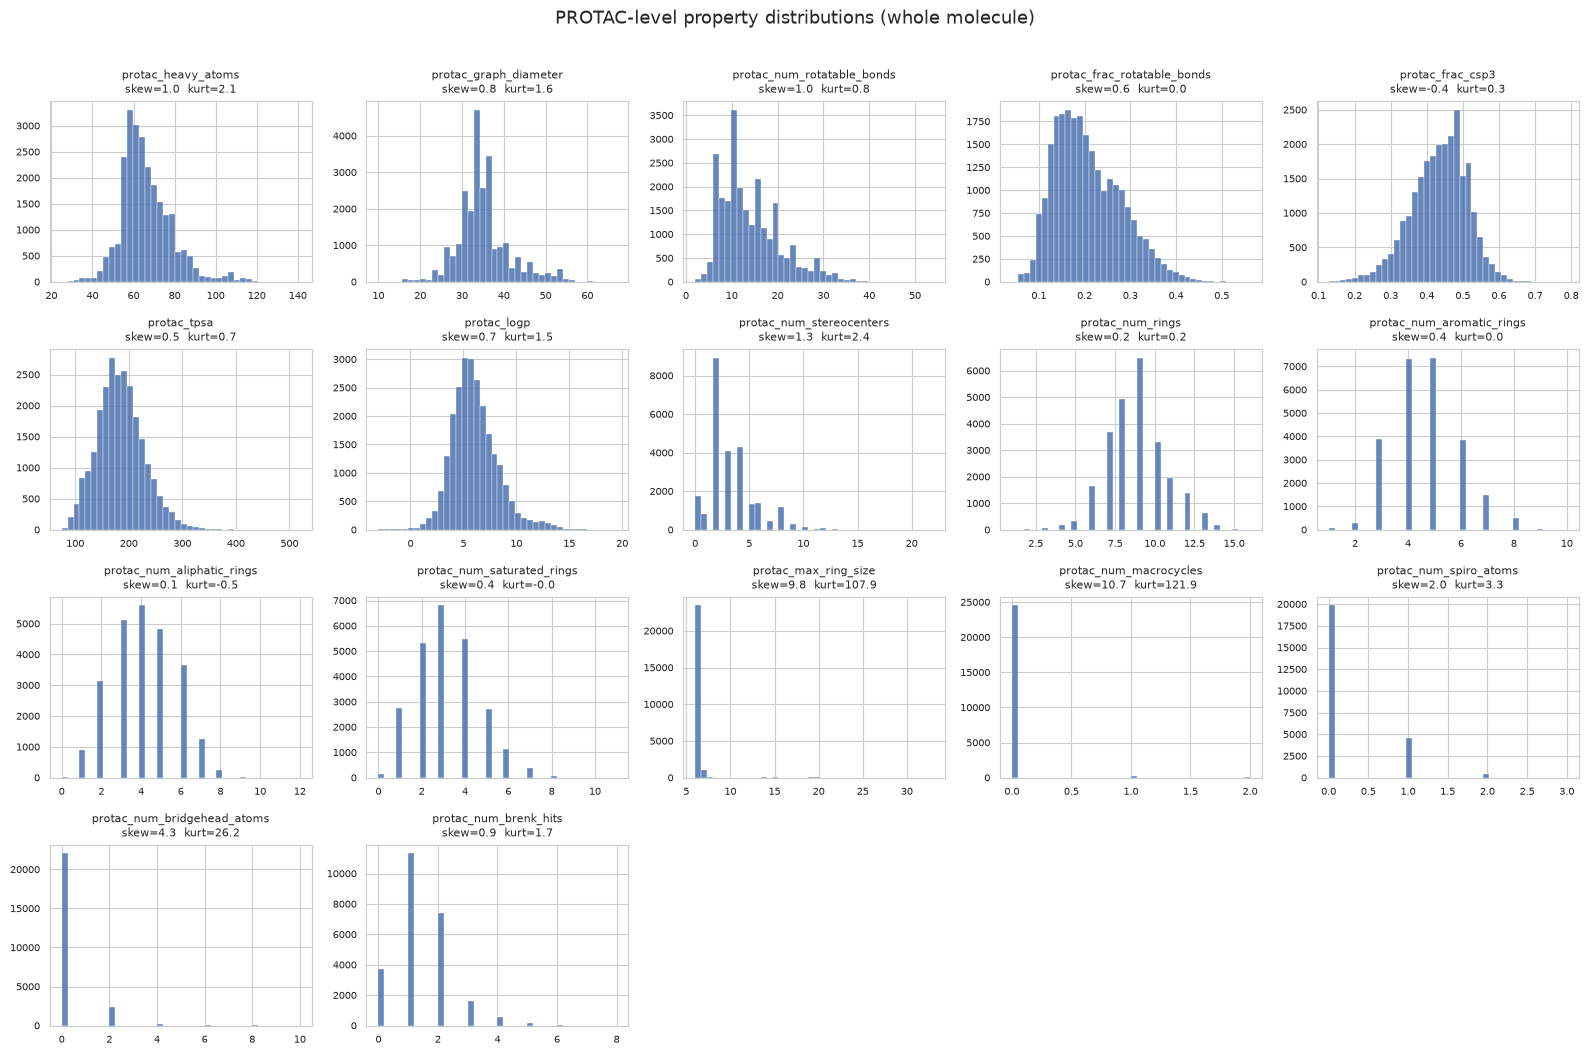

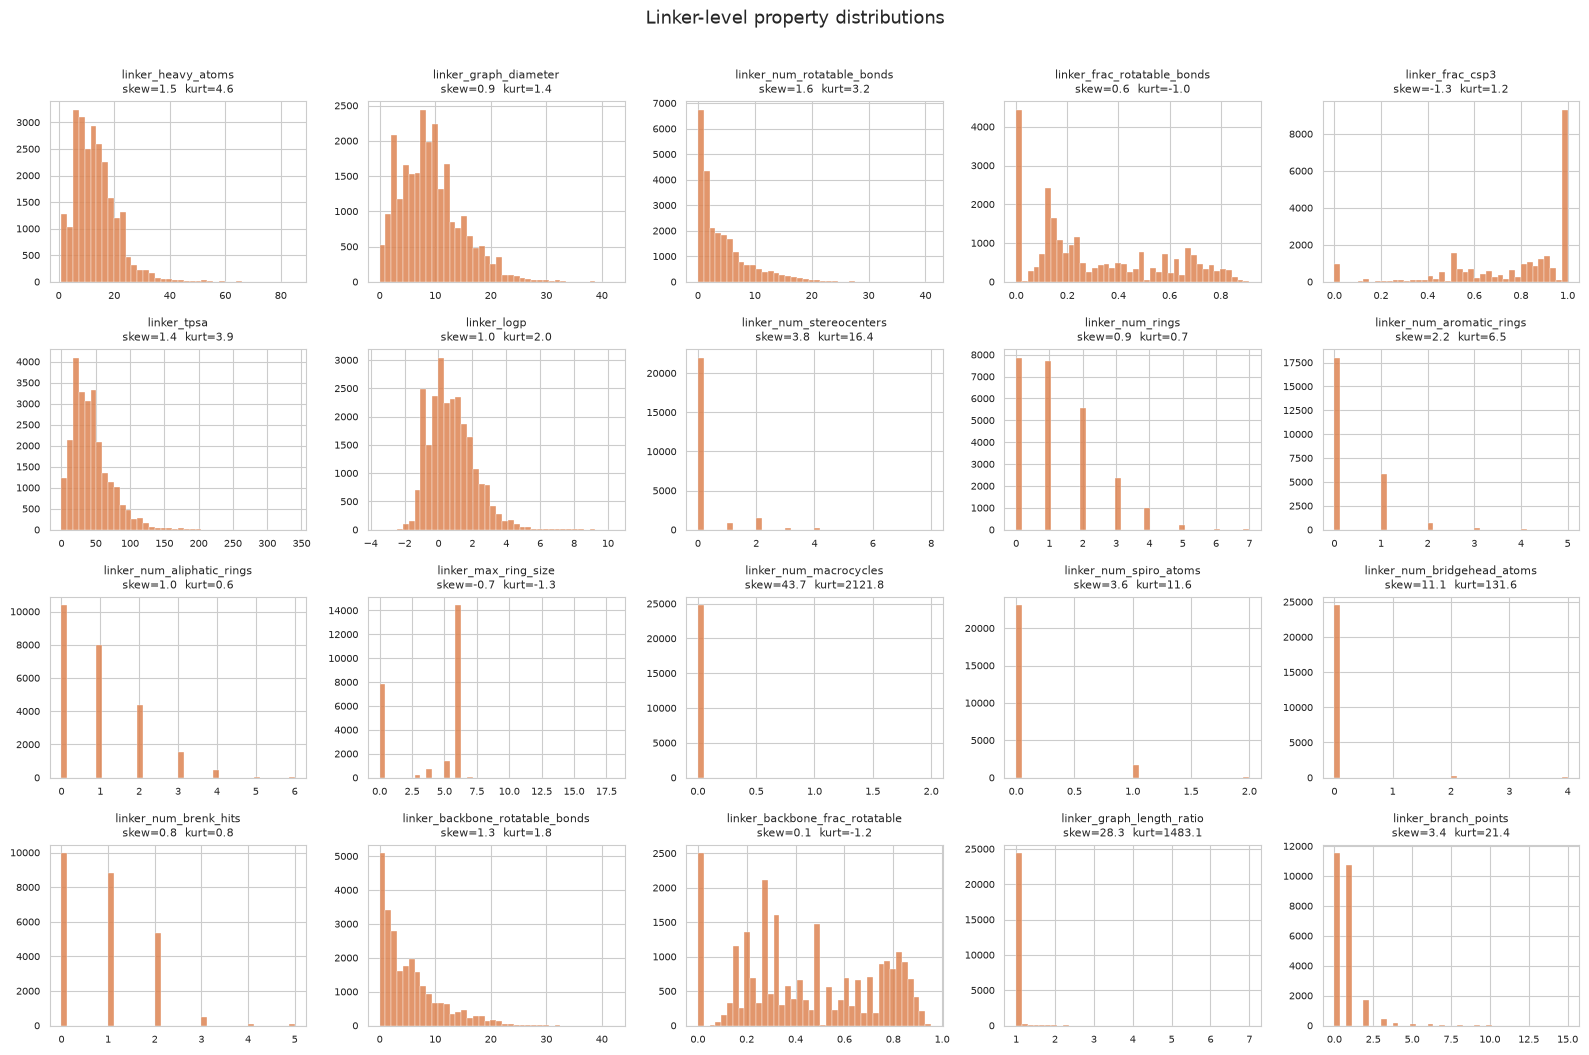

In [ ]:
def plot_distribution_grid(cols, df, title, ncols=5, color='#4C72B0'):
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 2.6))
    axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, cols):
        vals = df[col].dropna()
        ax.hist(vals, bins=40, color=color, alpha=0.85, edgecolor='white', linewidth=0.3)
        ax.set_title(f"{col}\nskew={stats.skew(vals):.1f}  kurt={stats.kurtosis(vals):.1f}", fontsize=8)
        ax.tick_params(labelsize=7)
    for ax in axes[len(cols):]:
        ax.axis('off')
    fig.suptitle(title, fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()

plot_distribution_grid(feature_groups['protac'], df, "PROTAC-level property distributions (whole molecule)")
plot_distribution_grid(feature_groups['linker'], df, "Linker-level property distributions", color='#DD8452')

In [ ]:
def skew_kurt_table(feature_groups, df):
    rows = []
    for grp, cols in feature_groups.items():
        for c in cols:
            vals = df[c].dropna()
            rows.append({
                'group': grp,
                'feature': c,
                'skew': stats.skew(vals),
                'excess_kurtosis': stats.kurtosis(vals),
                'n_missing': int(df[c].isna().sum()),
            })
    return pd.DataFrame(rows).sort_values('excess_kurtosis', ascending=False).reset_index(drop=True)

sk_table = skew_kurt_table(feature_groups, df)
print("Most leptokurtic (heavy-tailed / rare-extreme-value) features — poor candidates for plain z-score outlier flagging:")
sk_table.head(15)

Most leptokurtic (heavy-tailed / rare-extreme-value) features — poor candidates for plain z-score outlier flagging:


,group,feature,skew,excess_kurtosis,n_missing
0,e3,e3_num_macrocycles,78.549349,6168.000162,120
1,e3,e3_max_ring_size,35.615270,3187.104690,120
2,linker,linker_num_macrocycles,43.668563,2121.829171,48
3,linker,linker_graph_length_ratio,28.339232,1483.101354,0
4,poi,poi_sim_to_known_e3,10.179491,249.623406,1167
5,e3,e3_num_bridgehead_atoms,13.821704,198.384571,120
6,linker,linker_num_bridgehead_atoms,11.091122,131.619589,48
7,poi,poi_num_macrocycles,10.789293,123.270496,1167
8,protac,protac_num_macrocycles,10.705131,121.869982,0
9,protac,protac_max_ring_size,9.804049,107.879981,0


### Rule-based outlier / quality-control algorithm

Combines two complementary signals per molecule:

- **Statistical, per-feature flags** on the PROTAC- and linker-level numeric properties. Features with high excess kurtosis (heavy-tailed, mostly-constant-with-rare-extremes — e.g. `num_macrocycles`, `num_bridgehead_atoms`) are flagged by extreme percentile (>99.5th / <0.5th) instead of a z-score, since mean/std (or even MAD) z-scores are unstable on such distributions; the remaining, roughly unimodal features use a robust (median/MAD) z-score with |z| > 3.5. Each molecule gets an outlier *fraction* per group (protac, linker) = share of that group's features flagged.
- **Domain hard rules** that no distributional test would catch on its own: a missing E3/linker/POI fragment after splitting, a whole-PROTAC MW outside a plausible 400–2200 Da range, a "linker" with zero rotatable bonds but >8 heavy atoms (almost certainly a rigid ring system mis-assigned as linker, not a real flexible linker), or a linker with <2 heavy atoms (degenerate/near-empty).

The two signals combine into `rule_based_score` (linker weighted 1.5x protac, since the linker is the strongest tell per the task) and are thresholded at the 95th percentile, OR any hard rule firing, to get `rule_based_is_outlier`. The missing-fragment case is exactly why the hard rules matter: a row with an entirely missing linker has nothing to compute a z-score on, so it would otherwise slip through the statistical test unflagged.

rule_based_is_outlier rate: 8.4%


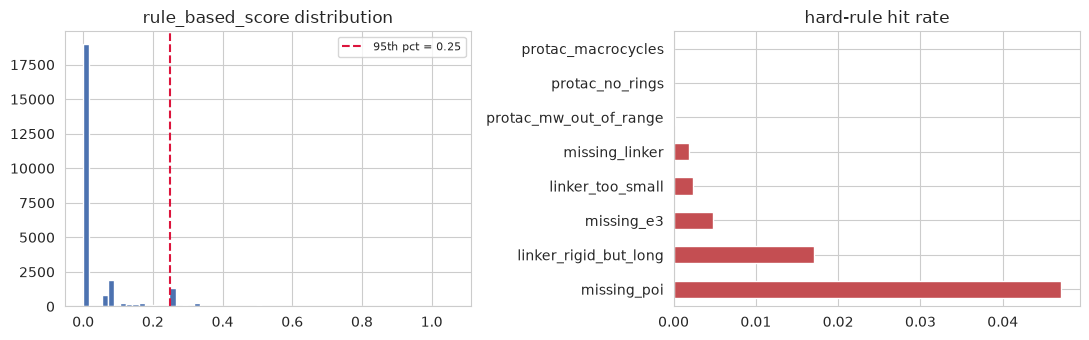

In [87]:
def robust_z(series):
    med = series.median()
    mad = stats.median_abs_deviation(series.dropna(), scale='normal')
    if mad == 0 or np.isnan(mad):
        return pd.Series(0.0, index=series.index)
    return (series - med) / mad

def feature_outlier_flags(cols, df, z_thresh=3.5, kurt_thresh=10.0, pct_thresh=0.995):
    flags = pd.DataFrame(index=df.index)
    for c in cols:
        vals = df[c]
        kurt = stats.kurtosis(vals.dropna())
        if abs(kurt) > kurt_thresh:
            hi, lo = vals.quantile(pct_thresh), vals.quantile(1 - pct_thresh)
            flags[c] = (vals > hi) | (vals < lo)
        else:
            flags[c] = robust_z(vals).abs() > z_thresh
        flags[c] = flags[c].fillna(False)
    return flags

protac_flags = feature_outlier_flags(feature_groups['protac'], df)
linker_flags = feature_outlier_flags(feature_groups['linker'], df)
df['rb_protac_outlier_frac'] = protac_flags.mean(axis=1)
df['rb_linker_outlier_frac'] = linker_flags.mean(axis=1)

hard_rules = pd.DataFrame(index=df.index)
hard_rules['missing_linker'] = df['linker_heavy_atoms'].isna()
hard_rules['missing_e3'] = df['e3_heavy_atoms'].isna()
hard_rules['missing_poi'] = df['poi_heavy_atoms'].isna()
hard_rules['protac_mw_out_of_range'] = ~df['protac_mw'].between(400, 2200)
hard_rules['protac_no_rings'] = df['protac_num_rings'] == 0
hard_rules['linker_rigid_but_long'] = (df['linker_num_rotatable_bonds'].fillna(-1) == 0) & (df['linker_heavy_atoms'].fillna(0) > 8)
hard_rules['linker_too_small'] = df['linker_heavy_atoms'].fillna(np.inf) < 2
hard_rules['protac_macrocycles'] = (df['protac_num_rotatable_bonds'].fillna(-1) == 0) & (df['protac_heavy_atoms'].fillna(0) > 8)
df['rb_hard_rule_hits'] = hard_rules.sum(axis=1)

w_protac, w_linker, w_hard = 1.0, 1.5, 2.0
df['rule_based_score'] = (
    w_protac * df['rb_protac_outlier_frac'] +
    w_linker * df['rb_linker_outlier_frac'] +
    w_hard * hard_rules.mean(axis=1)
)
score_thresh = df['rule_based_score'].quantile(0.95)
df['rule_based_is_outlier'] = (df['rule_based_score'] >= score_thresh) | (df['rb_hard_rule_hits'] > 0)

print(f"rule_based_is_outlier rate: {df['rule_based_is_outlier'].mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(df['rule_based_score'], bins=60, color='#4C72B0')
axes[0].axvline(score_thresh, color='crimson', ls='--', label=f'95th pct = {score_thresh:.2f}')
axes[0].set_title('rule_based_score distribution')
axes[0].legend(fontsize=8)
hard_rules.mean().sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='#C44E52')
axes[1].set_title('hard-rule hit rate')
fig.tight_layout()
plt.show()

Number of outliers: 2078
O=C1CCC(N2C(=O)c3ccc(N4CC(C#Cc5cnn(Cc6cnn(-c7c(Cl)cc(C(F)(F)F)cc7Cl)c6)c5)C4)cc3C2=O)C(=O)N1
0.25


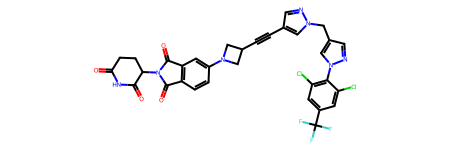

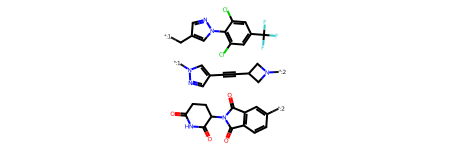

--------------------------------------------------------------------------------
Cc1ncsc1-c1ccc([C@H](CN2CCOCC2)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](n2cc([C@H]3CC[C@H](CN4CCC(c5ccc6c(c5)-n5c(nc(=O)c7c(Br)cccc75)C6(C)C)CC4)CC3)nn2)C(C)(C)C)cc1
0.25


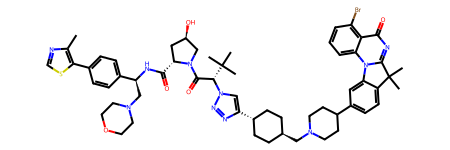

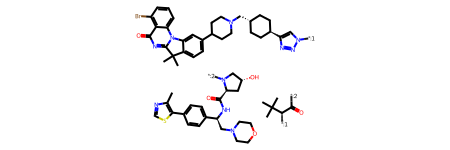

--------------------------------------------------------------------------------
CC1(C)C(=O)N(c2ccc(C#N)c(C(F)(F)F)c2)C(=S)N1c1ccc(C(=O)N2CCC3(CCC(N4CCC5(CCc6cc7c(cc6O5)C(=O)N(C5CCC(=O)NC5=O)C7=O)CC4)CC3)CC2)c(F)c1
0.25


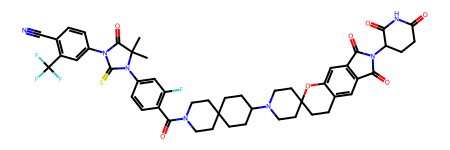

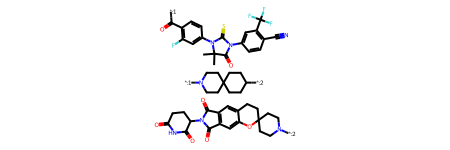

--------------------------------------------------------------------------------
C[C@@H]1Cc2cc(O)ccc2[C@@H](c2c(F)cc(N3CC4(CCN(C(=O)CN5Cc6cc7c(cc6C5)C(=O)N(C5CCC(=O)NC5=O)C7)CC4)C3)cc2F)N1CC(C)(F)F
0.25


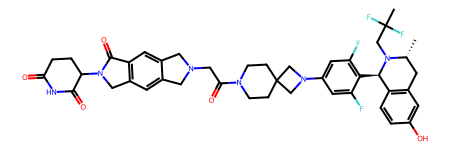

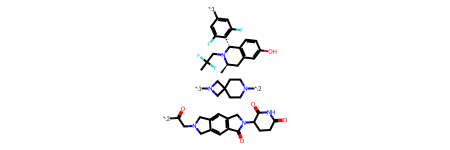

--------------------------------------------------------------------------------
CC(C)(C)c1cc(NC(=O)Nc2ccc(-c3cn(CCCc4cn(CCC(=O)Nc5cccc6c5CN(C5CCC(=O)NC5=O)C6=O)nn4)c4ncnc(N)c34)cc2)no1
0.25


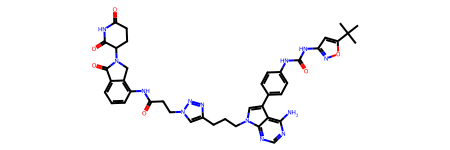

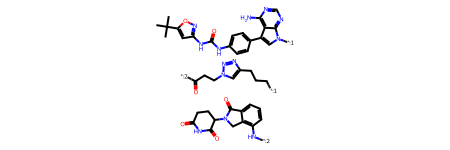

--------------------------------------------------------------------------------
COc1cc2nn([C@H]3CC[C@H](CN4CCN(c5ccc6c(c5)C5(CC5)C(=O)N6C5CCC(=O)NC5=O)CC4)CC3)cc2cc1C(=O)Nc1cnc2cccnn12
0.25


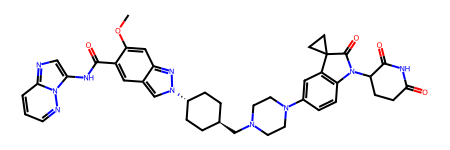

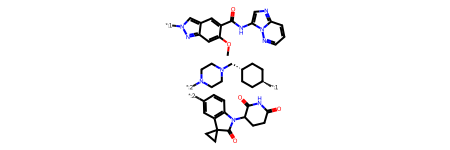

--------------------------------------------------------------------------------
Cc1ncsc1-c1ccc([C@H](CN2CCOCC2)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@H](C(C)C)n2cc([C@H]3CC[C@H](CN4CCC(c5ccc6c(c5)-n5c(nc(=O)c7c(Cl)cccc75)C6(C)C)CC4)CC3)nn2)cc1
0.25


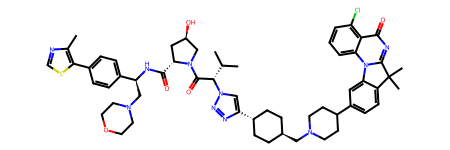

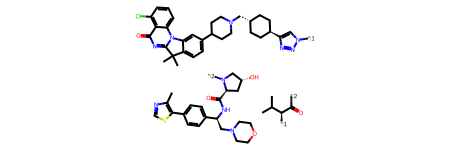

--------------------------------------------------------------------------------
COc1cc2nn(C3CCC(CCN4CCn5c(cc6cc(C7CCC(=O)NC7=O)ccc65)C4)CC3)cc2cc1NC(=O)C1CC=CC(C(F)(F)F)=N1
0.25


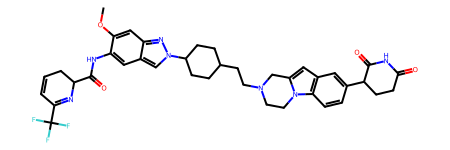

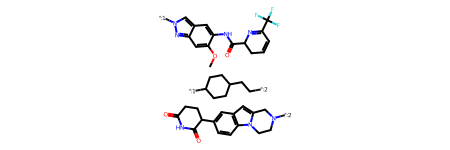

--------------------------------------------------------------------------------
COc1cc2nn([C@H]3CC[C@H](CN4CCN(c5ccc(C(=O)NC6CCC(=O)NC6=O)c(F)c5)CC4)CC3)cc2cc1C(=O)Nc1cccn(C2CC2)c1=O
0.25


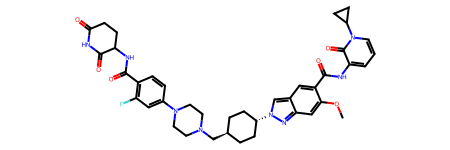

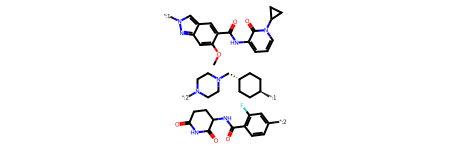

--------------------------------------------------------------------------------
O=C1CCC(N2Cc3c(OCCOCCOCCOCCn4cc(-c5ccc6c(c5)CC/C6=N\O)c(-c5ccncc5)n4)cccc3C2=O)C(=O)N1
0.25


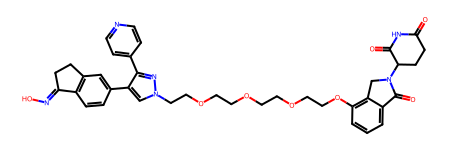

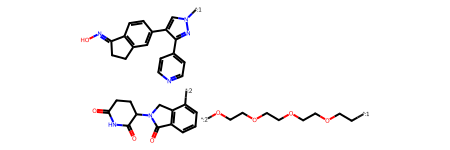

--------------------------------------------------------------------------------
CC(=O)N1CCc2c(c(N3CCCc4cc(-c5cnn(C)c5)c(C(F)F)cc43)nn2C[C@H]2CC[C@@H](N3CCc4cc5c(cc4C3)C(=O)N(C3CCC(=O)NC3=O)C5=O)CC2)C1
0.25


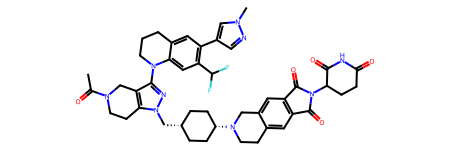

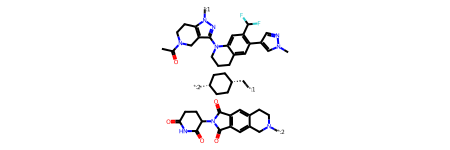

--------------------------------------------------------------------------------
N=c1c2c(-c3ccccc3)c(-c3ccccc3)n(Cc3cccc(C#CCCC(=O)NCCCNC(=O)CCCNc4cccc5c4C(=O)N(C4CCC(=O)NC4=O)C5=O)c3)c2ncn1[C@H]1CC[C@H](O)CC1
0.25


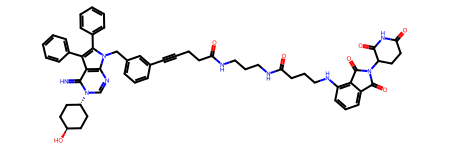

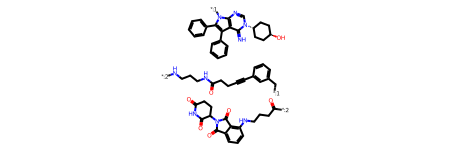

--------------------------------------------------------------------------------
COc1ccc(F)cc1C(=O)NCc1ccc(-c2nn(-c3ccc(N4CCN(CC5CCN(c6ccc(N7CCC(=O)NC7=O)c(C)c6)CC5)C[C@H]4C)nc3)c3ncnc(N)c23)cc1
0.325


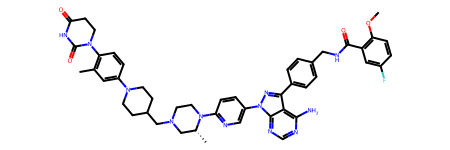

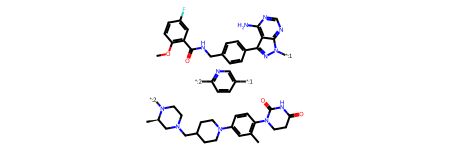

--------------------------------------------------------------------------------
Cc1ncsc1-c1cnc(C(C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)C(c2cc(OCCN3CCC(n4nc(N)c5nnc(-c6ccccc6O)cc54)CC3)no2)C(C)C)cn1
0.325


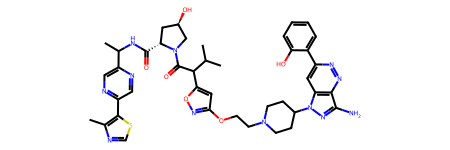

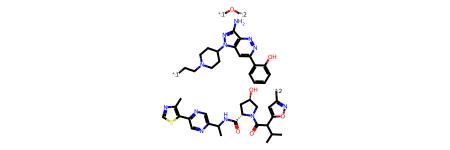

--------------------------------------------------------------------------------
Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)OCCOCCOCCOCCn2cc(CC/C=C(/C#N)C(=O)N3CCC[C@@H](n4nc(-c5ccc(Oc6ccccc6)cc5)c5c(N)ncnc54)C3)nn2)C(C)(C)C)cc1
0.35882352941176476


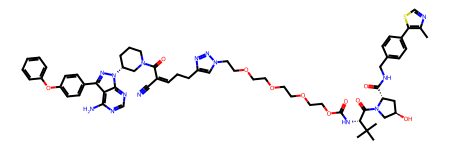

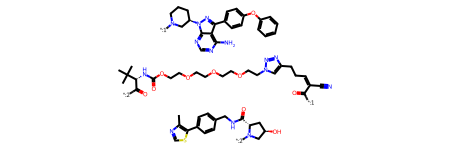

--------------------------------------------------------------------------------
C=C(CC)C(=O)c1ccc(OCC(=O)NCCCCCCCC(=O)C(CCCN/C(=N/C(=O)OC(C)(C)C)NC(=O)OC(C)(C)C)NC(=O)OC(C)(C)C)c(Cl)c1Cl
0.35882352941176476


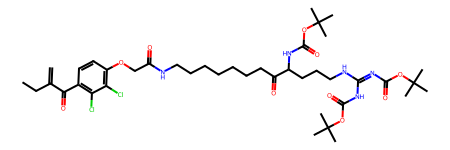

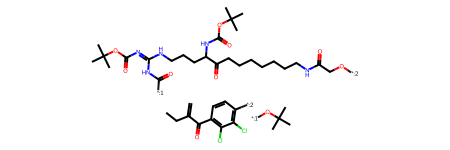

--------------------------------------------------------------------------------
Cc1c(Nc2nc3ccccc3s2)nnc2c1CCCN2c1ccc(-c2cnn(CC34CC5(C)CC(C)(C3)CC(OCCN(C)CCCCCCCC(=O)N3CCC(c6ccc7c(c6)CN(C6CCC(=O)NC6=O)C7=O)CC3)(C5)C4)c2C)c(C(=O)O)n1
0.4


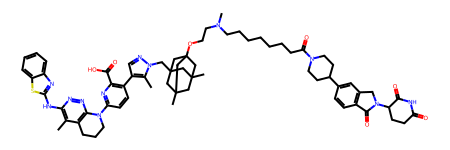

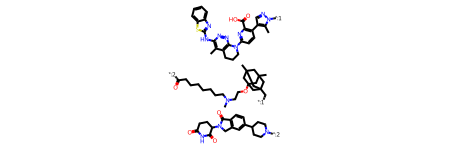

--------------------------------------------------------------------------------
Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCCC(=O)N2CCN(CC[C@H](CSc3ccccc3)Nc3ccc(S(=O)(=O)NC(=O)c4ccc(N5CCN(CC6=C(c7ccc(Cl)cc7)CCC7(C6)CN(C)C7)CC5)cc4)cc3S(=O)(=O)C(F)(F)F)CC2)C(C)(C)C)cc1
0.4176470588235295


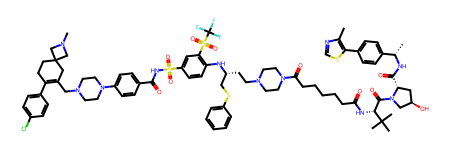

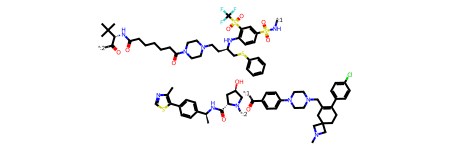

--------------------------------------------------------------------------------
Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCCCCC(=O)N2CCN(CC[C@H](CSc3ccccc3)Nc3ccc(S(=O)(=O)NC(=O)c4ccc(N5CCN(CC6=C(c7ccc(Cl)cc7)CCC(C)(C)C6)CC5)cc4)cc3S(=O)(=O)C(F)(F)F)CC2)C(C)C)cc1
0.5514705882352942


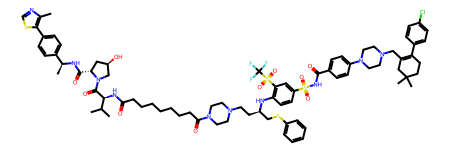

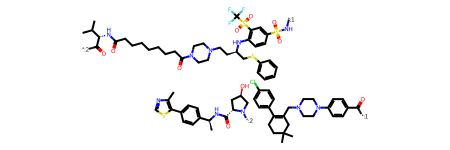

--------------------------------------------------------------------------------
Cc1cc(N(CCCCN(C)C(=O)CCCCCCCCCCCCSC(C)(C)[C@H](NC(=O)C2(F)CC2)C(=O)N2C[C@H](O)C[C@H]2C(=O)NCc2ccc(-c3scnc3C)cc2)c2ccc(-c3cnn(CC45CC6(C)CC(C)(C4)CC(OCCN(C)C)(C6)C5)c3C)c(C(=O)O)n2)nnc1Nc1nc2ccccc2s1
1.0602941176470588


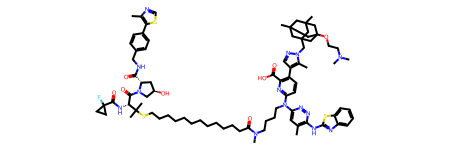

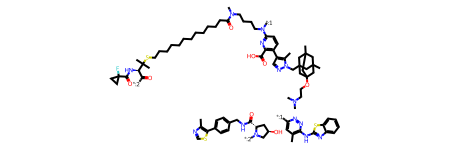

--------------------------------------------------------------------------------


In [88]:
from rdkit import Chem

def to_mol(smi):
    return Chem.MolFromSmiles(smi)

print(f"Number of outliers: {len(df[df['rule_based_is_outlier']])}")

for i, row in df[df['rule_based_is_outlier']].sample(n=20).sort_values(by="rule_based_score", ascending=True).reset_index().iterrows():
    print(row['SMILES'])
    print(row['rule_based_score'])
    display(to_mol(row['SMILES']))
    display(to_mol(row['default_pred_n0']))
    print('-' * 80)
    if i > 20:
        break

### Multivariate outlier detection: IsolationForest pipelines

Rule-based flags are univariate and hand-specified; they'll miss molecules that look normal on every feature *individually* but are jointly implausible. Four `sklearn` pipelines run IsolationForest — impute (median) → drop near-zero-variance features → standardize → (PCA, for the two larger feature sets) → IsolationForest with subsampling (`max_samples=0.8`) and bootstrapping (`bootstrap=True`) turned on — over four feature sets:

1. **PROTAC-only** — whole-molecule descriptors only.
2. **Linker-only** — linker descriptors only (the strongest single signal per the task).
3. **PROTAC + linker** — the two most informative fragments combined.
4. **All** (PROTAC + E3 + linker + POI) — full multivariate context, PCA-reduced since it's the highest-dimensional set.

**`contamination` tuning**: rather than an arbitrary constant, each pipeline's contamination is anchored to the rate the *rule-based* signal already flags on the matching feature subset (e.g. the linker-only IsolationForest is calibrated against how often linker features alone look statistically extreme), clipped to a `[1%, 10%]` domain-plausible band since non-PROTAC/mis-split molecules are expected to be a minority. This keeps the unsupervised contamination grounded in the same domain knowledge as the rule-based checks instead of guessing.

In [89]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

def build_isoforest_pipeline(n_features, contamination, use_pca=False, random_state=0):
    steps = [
        ('impute', SimpleImputer(strategy='median')),
        ('varthresh', VarianceThreshold(threshold=1e-6)),
        ('scale', StandardScaler()),
    ]
    if use_pca:
        steps.append(('pca', PCA(n_components=min(15, max(2, n_features // 2)), random_state=random_state)))
    steps.append(('isoforest', IsolationForest(
        n_estimators=300,
        max_samples=0.8,     # subsampling
        bootstrap=True,      # bootstrapping
        contamination=contamination,
        random_state=random_state,
        n_jobs=-1,
    )))
    return Pipeline(steps)

def domain_contamination(mask, lo=0.01, hi=0.10):
    return float(np.clip(mask.mean(), lo, hi))

protac_soft_outlier = df['rb_protac_outlier_frac'] >= df['rb_protac_outlier_frac'].quantile(0.95)
linker_soft_outlier = df['rb_linker_outlier_frac'] >= df['rb_linker_outlier_frac'].quantile(0.95)

feature_sets = {
    'protac_only': feature_groups['protac'],
    'linker_only': feature_groups['linker'],
    'protac_linker': feature_groups['protac'] + feature_groups['linker'],
    'all': feature_groups['protac'] + feature_groups['e3'] + feature_groups['linker'] + feature_groups['poi'],
}
contamination_settings = {
    'protac_only': domain_contamination(protac_soft_outlier),
    'linker_only': domain_contamination(linker_soft_outlier),
    'protac_linker': domain_contamination(df['rule_based_is_outlier']),
    'all': domain_contamination(df['rule_based_is_outlier']),
}

fitted_pipelines = {}
for name, cols in feature_sets.items():
    X = df[cols]
    use_pca = len(cols) > 20
    pipe = build_isoforest_pipeline(len(cols), contamination_settings[name], use_pca=use_pca)
    pipe.fit(X)
    df[f'if_{name}_is_outlier'] = pipe.predict(X) == -1
    df[f'if_{name}_score'] = -pipe.decision_function(X)  # flip sign: higher = more anomalous
    fitted_pipelines[name] = pipe
    print(f"{name:15s} n_features={len(cols):3d}  pca={use_pca!s:5}  "
          f"contamination={contamination_settings[name]:.3f}  "
          f"n_flagged={int(df[f'if_{name}_is_outlier'].sum())}")

protac_only     n_features= 17  pca=False  contamination=0.083  n_flagged=2050
linker_only     n_features= 20  pca=False  contamination=0.100  n_flagged=2482
protac_linker   n_features= 37  pca=True   contamination=0.084  n_flagged=2078
all             n_features= 76  pca=True   contamination=0.084  n_flagged=2078


good-quality PROTACs retained: 95.0% (23571 / 24812)


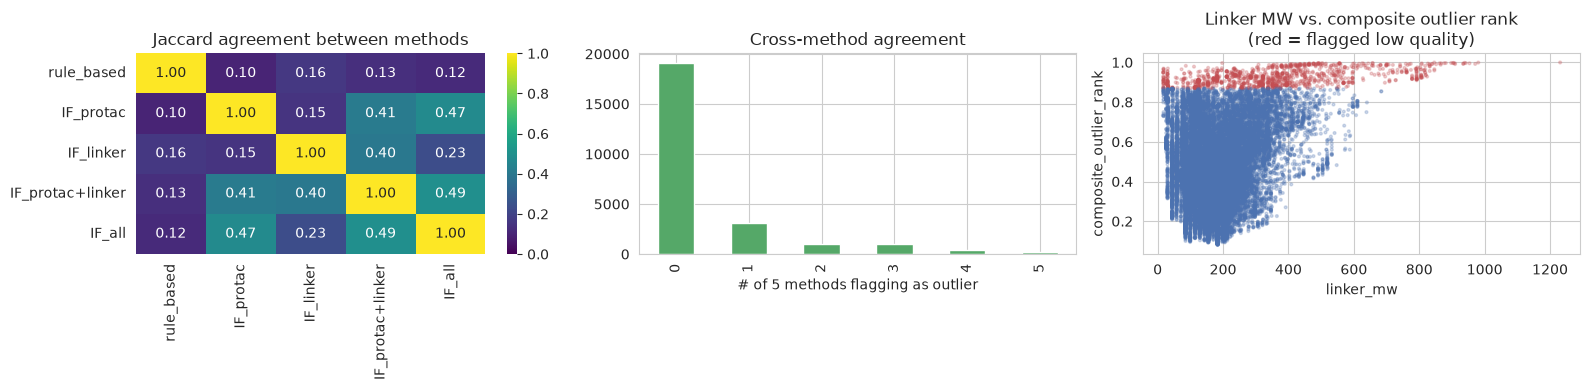

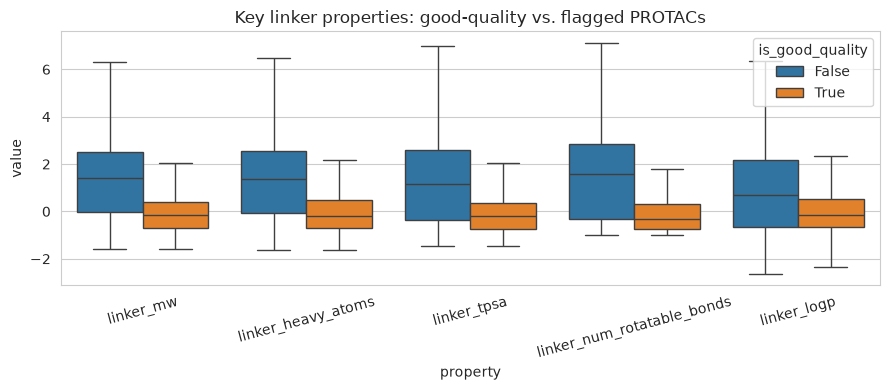

,SMILES,protac_mw,linker_mw,linker_heavy_atoms,rule_based_score,composite_outlier_rank
17195,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,2042.2,1230.8,85.0,0.701471,0.999516
2798,COC(=O)C(CCC(=O)NCCCCCCCCNc1cccc2c1C(=O)N(C1CC...,1409.5,845.9,59.0,0.760294,0.999504
4694,Cc1cc(N(CCCCN(C)C(=O)CCCCCCCCCCCCSC(C)(C)[C@H]...,1536.1,980.4,69.0,1.060294,0.999009
4709,Cc1cc(N(CCCCN(C)C(=O)CCCCCCCCCCCCC(=O)N[C@H](C...,1474.0,904.3,65.0,0.985294,0.997445
15947,Cc1cc(N(CCCCN(C)C(=O)CCCCCCCCCSC(C)(C)[C@H](NC...,1494.0,938.3,66.0,0.926471,0.997445
1763,CC1=C(C)C2=C(C1)n1c(C)nnc1[C@H](CC(=O)NCCOCCOC...,1648.8,897.5,61.0,0.685294,0.996993
16034,CC(C)(C)c1nc(-c2cccc(NS(=O)(=O)c3c(F)cccc3F)c2...,1415.6,656.8,45.0,0.610294,0.996792
5150,Cc1cc([C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)N[C@@H...,1275.9,197.3,14.0,0.383824,0.996594
12087,COCCOCC(=O)NC(C(=O)N1C[C@@H](OC(=O)CCc2cn(CCCC...,1830.2,942.1,66.0,0.819118,0.996453
7141,CC[C@H](C)[C@H](N)c1cn([C@@H](Cc2ccc(O)cc2)C(=...,1963.2,493.6,34.0,0.535294,0.996449


In [90]:
from scipy.stats import rankdata

score_cols = ['rule_based_score'] + [f'if_{n}_score' for n in feature_sets]
df['composite_outlier_rank'] = df[score_cols].apply(lambda s: rankdata(s) / len(s)).mean(axis=1)

quality_thresh = df['composite_outlier_rank'].quantile(0.95)
df['is_good_quality'] = df['composite_outlier_rank'] < quality_thresh
print(f"good-quality PROTACs retained: {df['is_good_quality'].mean():.1%} ({df['is_good_quality'].sum()} / {len(df)})")

is_outlier_cols = ['rule_based_is_outlier', 'if_protac_only_is_outlier', 'if_linker_only_is_outlier', 'if_protac_linker_is_outlier', 'if_all_is_outlier']
df['is_outlier'] = df[is_outlier_cols].any(axis=1)

flag_matrix = pd.DataFrame({
    'rule_based': df['rule_based_is_outlier'],
    'IF_protac': df['if_protac_only_is_outlier'],
    'IF_linker': df['if_linker_only_is_outlier'],
    'IF_protac+linker': df['if_protac_linker_is_outlier'],
    'IF_all': df['if_all_is_outlier'],
})

def jaccard(a, b):
    union = (a | b).sum()
    return (a & b).sum() / union if union else np.nan

names = list(flag_matrix.columns)
jac = pd.DataFrame([[jaccard(flag_matrix[a], flag_matrix[b]) for b in names] for a in names], index=names, columns=names)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.heatmap(jac, annot=True, fmt='.2f', cmap='viridis', vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('Jaccard agreement between methods')

flag_matrix.sum(axis=1).value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_xlabel('# of 5 methods flagging as outlier')
axes[1].set_title('Cross-method agreement')

axes[2].scatter(df['linker_mw'], df['composite_outlier_rank'], s=4, alpha=0.25,
                 c=np.where(df['is_good_quality'], '#4C72B0', '#C44E52'))
axes[2].set_xlabel('linker_mw')
axes[2].set_ylabel('composite_outlier_rank')
axes[2].set_title('Linker MW vs. composite outlier rank\n(red = flagged low quality)')
fig.tight_layout()
plt.show()

# boxplots earn their keep here: comparing kept vs. flagged groups on key linker properties
key_linker_props = ['linker_mw', 'linker_heavy_atoms', 'linker_tpsa', 'linker_num_rotatable_bonds', 'linker_logp']
# plot_df = df[key_linker_props + ['is_good_quality']].melt(id_vars='is_good_quality', var_name='property', value_name='value')

plot_df = df[key_linker_props + ['is_good_quality']].copy()
# z-normalize all properties
for c in key_linker_props:
    plot_df[c] = (plot_df[c] - plot_df[c].mean()) / plot_df[c].std()
plot_df = plot_df.melt(id_vars='is_good_quality', var_name='property', value_name='value')

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=plot_df, x='property', y='value', hue='is_good_quality', ax=ax, showfliers=False)
ax.set_title('Key linker properties: good-quality vs. flagged PROTACs')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

review_cols = ['SMILES', 'protac_mw', 'linker_mw', 'linker_heavy_atoms', 'rule_based_score', 'composite_outlier_rank']
df.sort_values('composite_outlier_rank', ascending=False)[review_cols].head(20)

5715
TPDdb
Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)COCC(COCCOCCOCCNc2cc3c(cc2F)C(=O)N(C2CCC(=O)NC2=O)C3=O)(COCCOCCOCCOC(=O)C[C@@H]2N=C(c3ccc(Cl)cc3)c3c(sc(C)c3C)-n3c(C)nnc32)COCCOCCOCCOC(=O)C[C@@H]2N=C(c3ccc(Cl)cc3)c3c(sc(C)c3C)-n3c(C)nnc32)C(C)(C)C)cc1


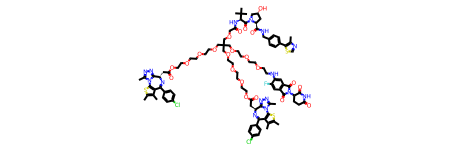

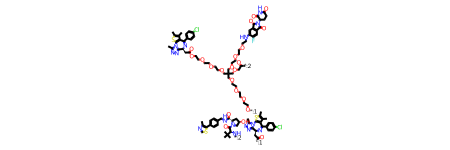

--------------------------------------------------------------------------------
TPDdb
COC(=O)C(CCC(=O)NCCCCCCCCNc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O)NC(=O)CC[C@H](NC(=O)CC[C@H](NC(=O)CC[C@H](NC(=O)CC[C@H](NC(=O)c1ccc(N(C)Cc2cnc3nc(N)nc(N)c3n2)cc1)C(=O)O)C(=O)OC)C(=O)OC)C(=O)OC


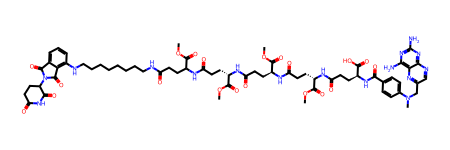

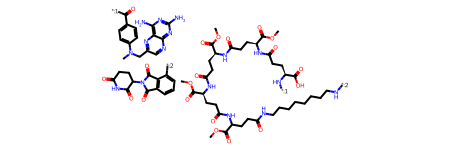

--------------------------------------------------------------------------------
TPDdb
Cc1cc(N(CCCCN(C)C(=O)CCCCCCCCCCCCSC(C)(C)[C@H](NC(=O)C2(F)CC2)C(=O)N2C[C@H](O)C[C@H]2C(=O)NCc2ccc(-c3scnc3C)cc2)c2ccc(-c3cnn(CC45CC6(C)CC(C)(C4)CC(OCCN(C)C)(C6)C5)c3C)c(C(=O)O)n2)nnc1Nc1nc2ccccc2s1


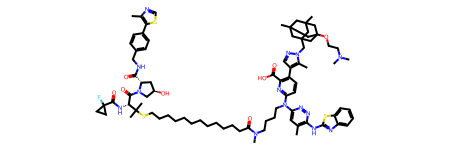

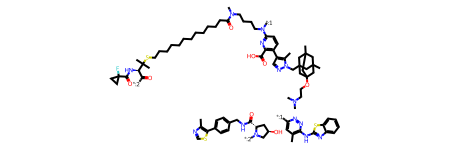

--------------------------------------------------------------------------------
TPDdb
Cc1cc(N(CCCCN(C)C(=O)CCCCCCCCCCCCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)N[C@@H](C)c2ccc(-c3scnc3C)cc2)C(C)(C)C)c2ccc(-c3cnn(CC45CC6(C)CC(C)(C4)CC(OCCN(C)C)(C6)C5)c3C)c(C(=O)O)n2)nnc1Nc1nc2ccccc2s1


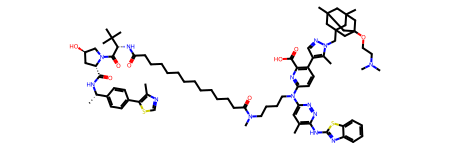

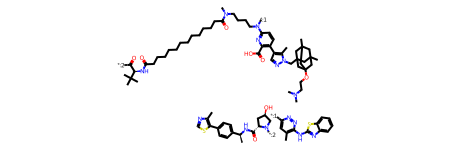

--------------------------------------------------------------------------------
TPDdb
Cc1cc(N(CCCCN(C)C(=O)CCCCCCCCCSC(C)(C)[C@H](NC(=O)C2(F)CC2)C(=O)N2C[C@H](O)C[C@H]2C(=O)NCc2ccc(-c3scnc3C)cc2)c2ccc(-c3cnn(CC45CC6(C)CC(C)(C4)CC(OCCN(C)C)(C6)C5)c3C)c(C(=O)O)n2)nnc1Nc1nc2ccccc2s1


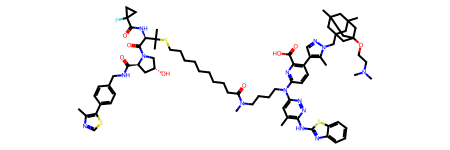

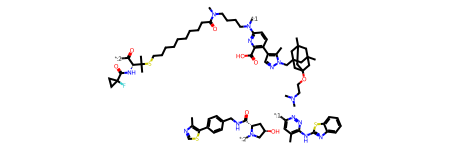

--------------------------------------------------------------------------------
TPDdb
CC1=C(C)C2=C(C1)n1c(C)nnc1[C@H](CC(=O)NCCOCCOCCOCCOCC(C)(COCCOCCOCCOCCNC(O)C[C@@H]1N=C(c3ccc(Cl)cc3)c3c(sc(C)c3C)-n3c(C)nnc31)COCC(=O)N[C@@H](C)C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1ccc(-c3scnc3C)cc1)N=C2c1ccc(Cl)cc1


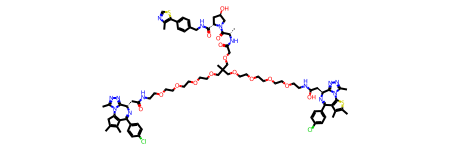

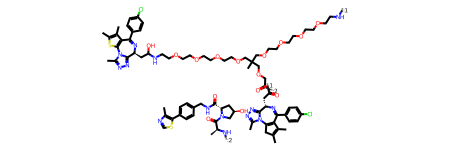

--------------------------------------------------------------------------------
PROTAC-DB
CC(C)(C)c1nc(-c2cccc(NS(=O)(=O)c3c(F)cccc3F)c2F)c(-c2ccnc(NCCCNC(=O)CCOCCOCCOCCOCCOCCNC(=O)CCOCCOCCOCCOCCOCCNc3cccc4c3C(=O)N(C3CCC(=O)NC3=O)C4=O)n2)s1


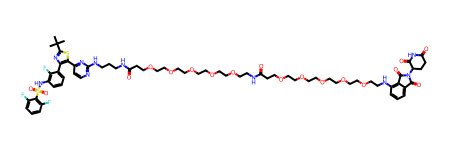

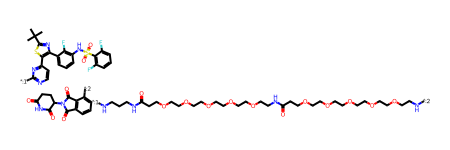

--------------------------------------------------------------------------------
TPDdb
Cc1cc([C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)N[C@@H](CC(=O)N2CCC3CCN(CC3)CCN(CC#Cc3ccc(OCCCc4ccc(N5CCc6cccc(C(=O)Nc7nc8ccccc8s7)c6C5)nc4C(=O)O)c(F)c3)CC2)c2ccc(Cl)cc2)C(C)C)on1


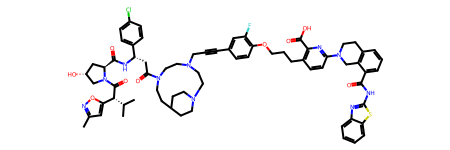

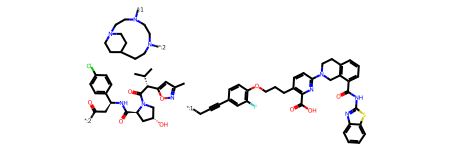

--------------------------------------------------------------------------------
TPDdb
COCCOCC(=O)NC(C(=O)N1C[C@@H](OC(=O)CCc2cn(CCCCCC(=O)OC(CCCOCCOCC(=O)N[C@H](C(=O)N3C[C@H](O)C[C@H]3C(=O)N[C@@H](C)c3ccc(-c4scnc4C)cc3)C(C)(C)C)CCOc3ccc(N4C(=S)N(c5ccc(C#N)c(C(F)(F)F)c5)C(=O)C4(C)C)cc3)nn2)C[C@H]1C(=O)N[C@@H](C)c1ccc(-c2scnc2C)cc1)C(C)(C)C


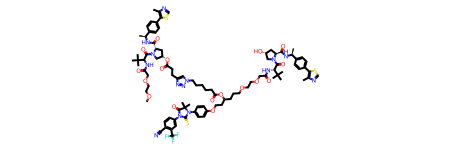

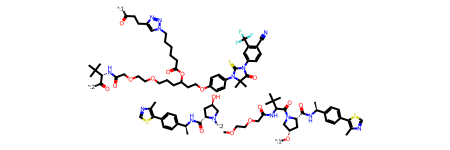

--------------------------------------------------------------------------------
PROTAC-DB; PROTACpedia
CC[C@H](C)[C@H](N)c1cn([C@@H](Cc2ccc(O)cc2)C(=O)N2CCN(c3nc(NCCOCCOCCOCc4cn(CCOCCOCCOCCOCCOCCNC(=O)CN5CCN(C(=O)N6C(c7ccc(OC)cc7OC(C)C)=N[C@@H](c7ccc(Cl)cc7)[C@H]6c6ccc(Cl)cc6)CC5=O)nn4)nc(N4CCN(C(=O)[C@H](Cc5ccc(O)cc5)n5cc([C@@H](N)[C@@H](C)CC)nn5)CC4)n3)CC2)nn1


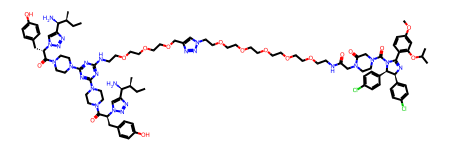

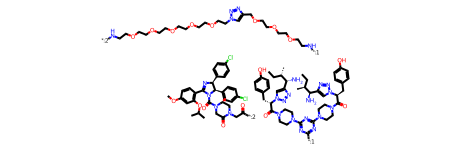

--------------------------------------------------------------------------------
TPDdb
Cc1cc(N(CCCCN(C)C(=O)CCCCCCCCCCCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)N[C@@H](C)c2ccc(-c3scnc3C)cc2)C(C)(C)C)c2ccc(-c3cnn(C[C@@]45C[C@@]6(C)C[C@@](O)(C4)C[C@](OCCN(C)C)(C6)C5)c3C)c(C(=O)O)n2)nnc1Nc1nc2ccccc2s1


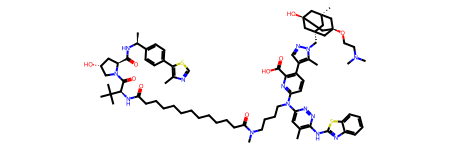

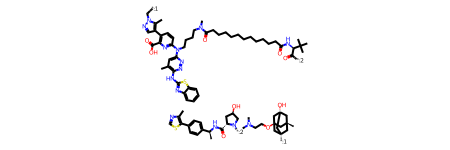

--------------------------------------------------------------------------------
TPDdb
Cc1cc(N(CCCCN(C)C(=O)CCCCCCCCCCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)N[C@@H](C)c2ccc(-c3scnc3C)cc2)C(C)(C)C)c2ccc(-c3cnn(CC45CC6(C)CC(C)(C4)CC(OCCN(C)C)(C6)C5)c3C)c(C(=O)N(C)C)n2)nnc1Nc1nc2ccccc2s1


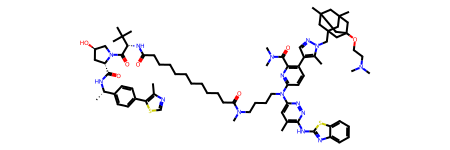

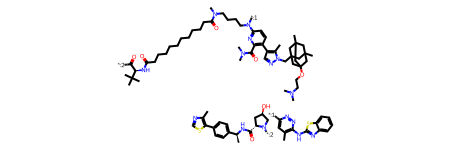

--------------------------------------------------------------------------------
TPDdb
Cc1c(Nc2nc3ccccc3s2)nnc2c1CCCN2c1ccc(-c2cnn(CC34CC5(C)CC(C)(C3)CC(OCCN(C)CCCCCCCCCCCCCCCC(=O)N3CCC(c6ccc7c(c6)CN(C6CCC(=O)NC6=O)C7=O)CC3)(C5)C4)c2C)c(C(=O)O)n1


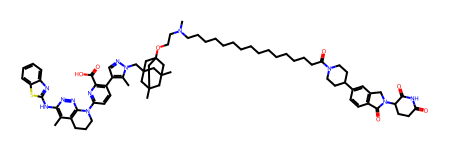

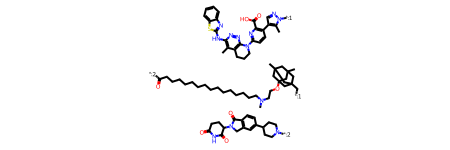

--------------------------------------------------------------------------------
TPDdb
Cc1cc(N(CCCCN(C)C(=O)CCCCCCCCCCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)N[C@@H](C)c2ccc(-c3scnc3C)cc2)C(C)(C)C)c2ccc(-c3cnn(CC45CC6(C)CC(C)(C4)CC(OCCN(C)C)(C6)C5)c3C)c(C(=O)O)n2)nnc1Nc1nc2ccccc2s1


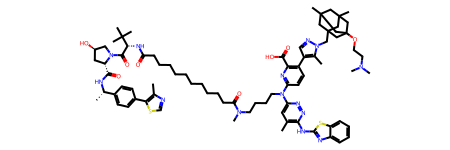

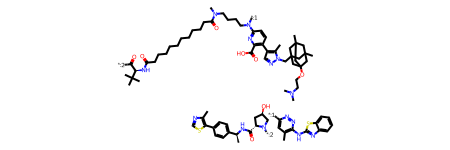

--------------------------------------------------------------------------------
TPDdb
Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@H](C)NC(=O)COCC(C)(COCCOCCOCCOCCN=NC(=O)C[C@@H]2N=C(c3ccc(Cl)cc3)c3c(sc(C)c3C)-n3c(C)nnc32)COCCOCCOCCOCCNC(=O)C[C@@H]2N=C(c3ccc(Cl)cc3)c3c(sc(C)c3C)-n3c(C)nnc32)cc1


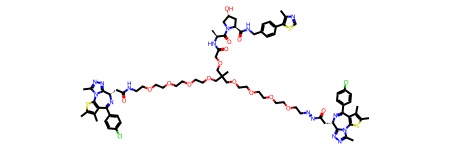

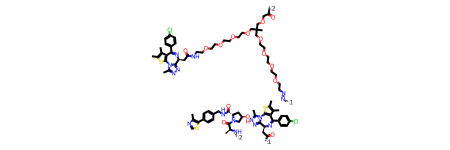

--------------------------------------------------------------------------------
PROTAC-DB
O=C1CCC(N2C(=O)c3cccc(NCCOCCOCCOCCOCCOCCOCCOCCOCCOCCNCCNc4nonc4/C(=N\O)Nc4ccc(F)c(Br)c4)c3C2=O)C(=O)N1


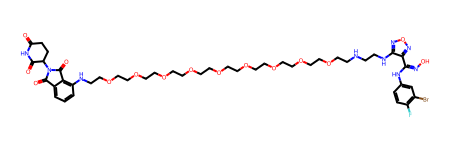

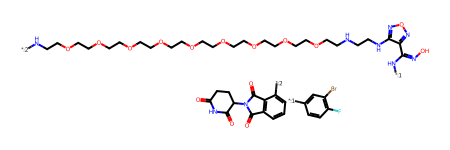

--------------------------------------------------------------------------------
PROTACpedia
Nc1nc2c(ncn2[C@H]2O[C@@H](COP(=O)(O)OP(=O)(O)NCCOCCOCCOCCOCCOCCOCCOCCC(=O)Nc3cccc4c3CN(C3CCC(=O)NC3=O)C4=O)[C@H](O)[C@@H]2O)c(=O)[nH]1


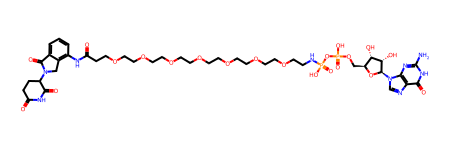

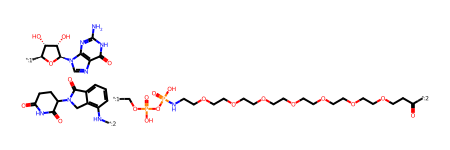

--------------------------------------------------------------------------------
TPDdb
Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)C2(F)CC2)C(C)(C)C)c(OCCCCCCCCCCCCCCCCN(C)CCOC23CC4(C)CC(C)(CC(Cn5ncc(-c6ccc(N7CCCc8c7nnc(Nc7nc9ccccc9s7)c8C)nc6C(=O)O)c5C)(C4)C2)C3)c1


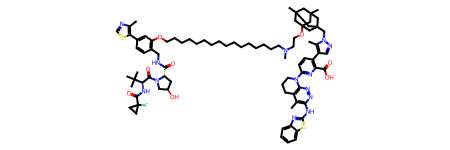

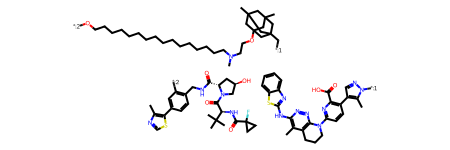

--------------------------------------------------------------------------------
TPDdb
CO[C@H]1C[C@@H]2CC[C@@H](C)[C@@](O)(O2)C(=O)C(=O)N2CCCC[C@H]2C(=O)O[C@H]([C@H](C)C[C@H]2CC[C@@H](OCCOc3cn(CCOCCOCCOCCOCCNc4cccc5c4C(=O)N(C4CCC(=O)NC4=O)C5=O)nn3)[C@H](OC)C2)CC(=O)[C@H](C)/C=C(\C)[C@@H](O)[C@@H](OC)C(=O)[C@H](C)C[C@H](C)/C=C/C=C/C=C/1C


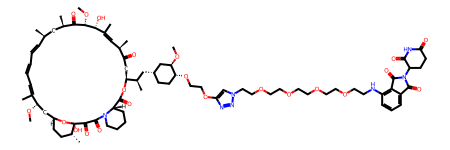

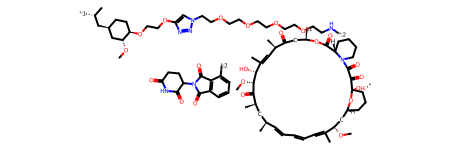

--------------------------------------------------------------------------------
TPDdb
Cc1cc(N(CCCCN(C)C(=O)CCCCCCCCCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)N[C@@H](C)c2ccc(-c3scnc3C)cc2)C(C)(C)C)c2ccc(-c3cnn(CC45CC6(C)CC(C)(C4)CC(OCCN(C)C)(C6)C5)c3C)c(C(=O)O)n2)nnc1Nc1nc2ccccc2s1


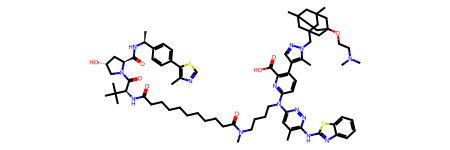

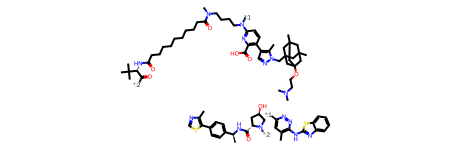

--------------------------------------------------------------------------------
TPDdb
Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)C2CCN(C(=O)CCCCCCCCCCCN(C)CCOC34CC5(C)CC(C)(CC(Cn6ncc(-c7ccc(N8CCCc9c8nnc(Nc8nc%10ccccc%10s8)c9C)nc7C(=O)O)c6C)(C5)C3)C4)CC2)C(C)(C)C)cc1


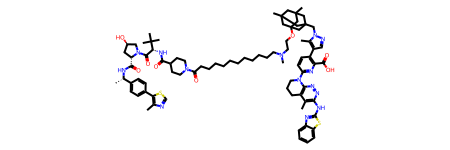

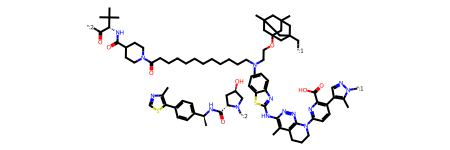

--------------------------------------------------------------------------------
TPDdb
C=C1CCC(N2C(=O)c3cccc(NCCNC(=O)COCC(C)(COCCOCCOCCOCCNC(=O)C[C@@H]4N=C(c5ccc(Cl)cc5)c5c(sc(C)c5C)-n5c(C)nnc54)COCCOCCOCCOCCNC(=O)C[C@@H]4N=C(c5ccc(Cl)cc5)c5c(sc(C)c5C)-n5c(C)nnc54)c3C2=O)C(=O)N1


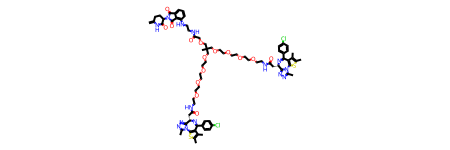

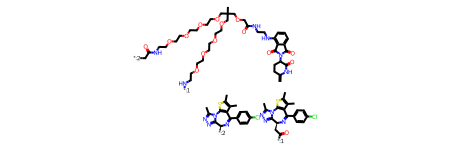

--------------------------------------------------------------------------------


In [91]:
print(len(df[df['is_outlier']]))

for i, row in df[df['is_outlier']].sort_values('composite_outlier_rank', ascending=False).reset_index().iterrows():
    print(row['Database'])
    print(row['SMILES'])
    # display(row)
    display(to_mol(row['SMILES']))
    display(to_mol(row['default_pred_n0']))
    print('-' * 80)
    if i > 20:
        break

TPDdb
Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)COCC(COCCOCCOCCNc2cc3c(cc2F)C(=O)N(C2CCC(=O)NC2=O)C3=O)(COCCOCCOCCOC(=O)C[C@@H]2N=C(c3ccc(Cl)cc3)c3c(sc(C)c3C)-n3c(C)nnc32)COCCOCCOCCOC(=O)C[C@@H]2N=C(c3ccc(Cl)cc3)c3c(sc(C)c3C)-n3c(C)nnc32)C(C)(C)C)cc1


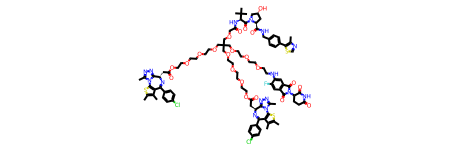

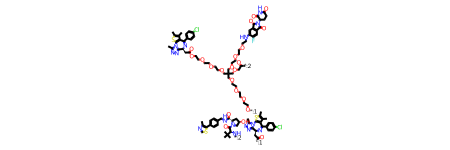

--------------------------------------------------------------------------------
TPDdb
COC(=O)C(CCC(=O)NCCCCCCCCNc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O)NC(=O)CC[C@H](NC(=O)CC[C@H](NC(=O)CC[C@H](NC(=O)CC[C@H](NC(=O)c1ccc(N(C)Cc2cnc3nc(N)nc(N)c3n2)cc1)C(=O)O)C(=O)OC)C(=O)OC)C(=O)OC


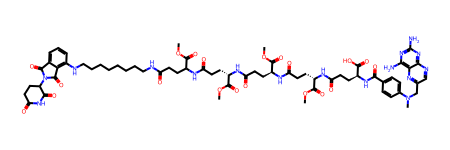

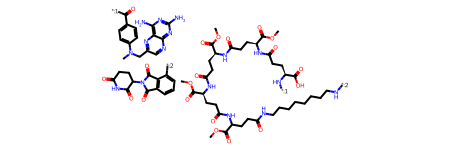

--------------------------------------------------------------------------------
TPDdb
Cc1cc(N(CCCCN(C)C(=O)CCCCCCCCCCCCSC(C)(C)[C@H](NC(=O)C2(F)CC2)C(=O)N2C[C@H](O)C[C@H]2C(=O)NCc2ccc(-c3scnc3C)cc2)c2ccc(-c3cnn(CC45CC6(C)CC(C)(C4)CC(OCCN(C)C)(C6)C5)c3C)c(C(=O)O)n2)nnc1Nc1nc2ccccc2s1


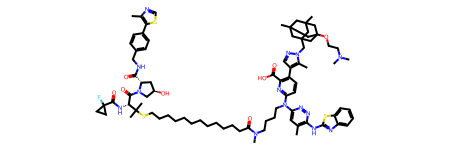

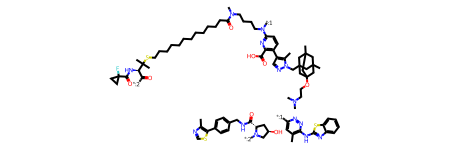

--------------------------------------------------------------------------------
TPDdb
Cc1cc(N(CCCCN(C)C(=O)CCCCCCCCCSC(C)(C)[C@H](NC(=O)C2(F)CC2)C(=O)N2C[C@H](O)C[C@H]2C(=O)NCc2ccc(-c3scnc3C)cc2)c2ccc(-c3cnn(CC45CC6(C)CC(C)(C4)CC(OCCN(C)C)(C6)C5)c3C)c(C(=O)O)n2)nnc1Nc1nc2ccccc2s1


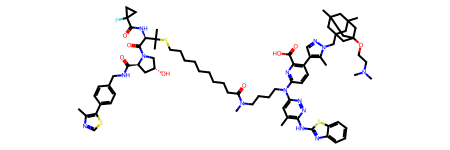

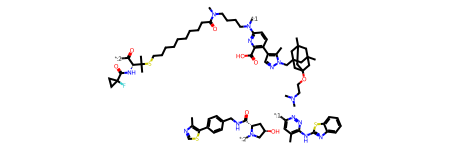

--------------------------------------------------------------------------------
TPDdb
CC1=C(C)C2=C(C1)n1c(C)nnc1[C@H](CC(=O)NCCOCCOCCOCCOCC(C)(COCCOCCOCCOCCNC(O)C[C@@H]1N=C(c3ccc(Cl)cc3)c3c(sc(C)c3C)-n3c(C)nnc31)COCC(=O)N[C@@H](C)C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1ccc(-c3scnc3C)cc1)N=C2c1ccc(Cl)cc1


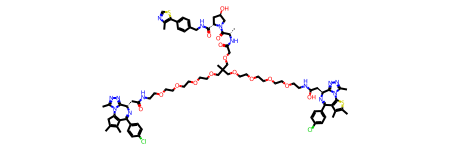

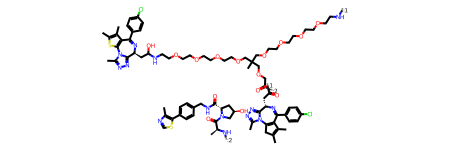

--------------------------------------------------------------------------------
TPDdb
Cc1cc(N(CCCCN(C)C(=O)CCCCCCCCCCCCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)N[C@@H](C)c2ccc(-c3scnc3C)cc2)C(C)(C)C)c2ccc(-c3cnn(CC45CC6(C)CC(C)(C4)CC(OCCN(C)C)(C6)C5)c3C)c(C(=O)O)n2)nnc1Nc1nc2ccccc2s1


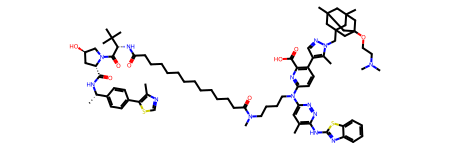

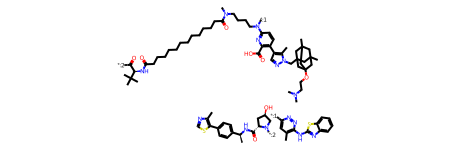

--------------------------------------------------------------------------------
TPDdb
COCCOCC(=O)NC(C(=O)N1C[C@@H](OC(=O)CCc2cn(CCCCCC(=O)OC(CCCOCCOCC(=O)N[C@H](C(=O)N3C[C@H](O)C[C@H]3C(=O)N[C@@H](C)c3ccc(-c4scnc4C)cc3)C(C)(C)C)CCOc3ccc(N4C(=S)N(c5ccc(C#N)c(C(F)(F)F)c5)C(=O)C4(C)C)cc3)nn2)C[C@H]1C(=O)N[C@@H](C)c1ccc(-c2scnc2C)cc1)C(C)(C)C


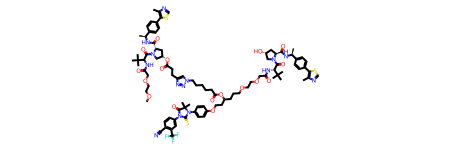

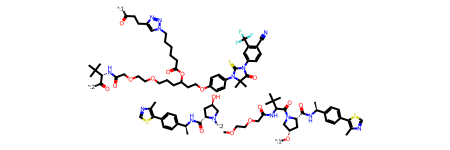

--------------------------------------------------------------------------------
TPDdb
Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@H](C)NC(=O)COCC(C)(COCCOCCOCCOCCN=NC(=O)C[C@@H]2N=C(c3ccc(Cl)cc3)c3c(sc(C)c3C)-n3c(C)nnc32)COCCOCCOCCOCCNC(=O)C[C@@H]2N=C(c3ccc(Cl)cc3)c3c(sc(C)c3C)-n3c(C)nnc32)cc1


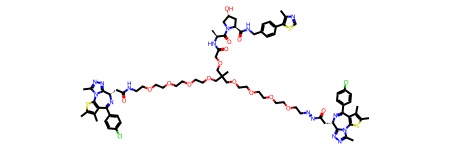

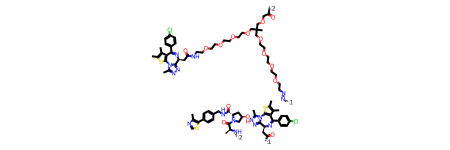

--------------------------------------------------------------------------------
TPDdb
Cc1cc(N(CCCCN(C)C(=O)CCCCCCCCCCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)N[C@@H](C)c2ccc(-c3scnc3C)cc2)C(C)(C)C)c2ccc(-c3cnn(CC45CC6(C)CC(C)(C4)CC(OCCN(C)C)(C6)C5)c3C)c(C(=O)N(C)C)n2)nnc1Nc1nc2ccccc2s1


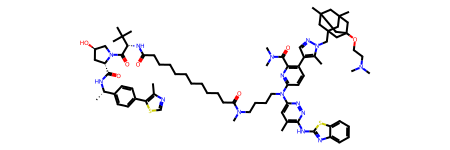

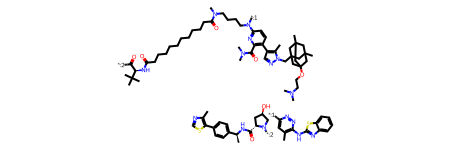

--------------------------------------------------------------------------------
PROTAC-DB
CC(C)(C)c1nc(-c2cccc(NS(=O)(=O)c3c(F)cccc3F)c2F)c(-c2ccnc(NCCCNC(=O)CCOCCOCCOCCOCCOCCNC(=O)CCOCCOCCOCCOCCOCCNc3cccc4c3C(=O)N(C3CCC(=O)NC3=O)C4=O)n2)s1


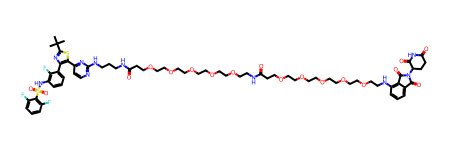

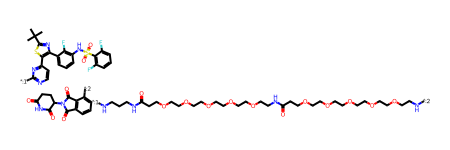

--------------------------------------------------------------------------------
TPDdb
Cc1cc(N(CCCCN(C)C(=O)CCCCCCCCCCCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)N[C@@H](C)c2ccc(-c3scnc3C)cc2)C(C)(C)C)c2ccc(-c3cnn(C[C@@]45C[C@@]6(C)C[C@@](O)(C4)C[C@](OCCN(C)C)(C6)C5)c3C)c(C(=O)O)n2)nnc1Nc1nc2ccccc2s1


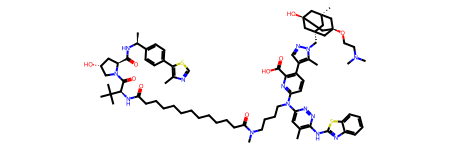

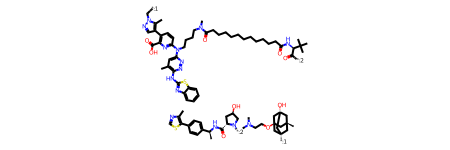

--------------------------------------------------------------------------------
TPDdb
Cc1cc(N(CCCCN(C)C(=O)CCCCCCCCCCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)N[C@@H](C)c2ccc(-c3scnc3C)cc2)C(C)(C)C)c2ccc(-c3cnn(CC45CC6(C)CC(C)(C4)CC(OCCN(C)C)(C6)C5)c3C)c(C(=O)O)n2)nnc1Nc1nc2ccccc2s1


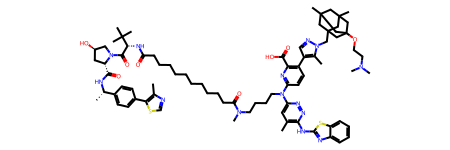

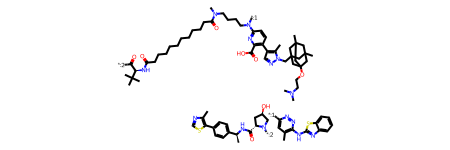

--------------------------------------------------------------------------------
PROTAC-DB; PROTACpedia
CC[C@H](C)[C@H](N)c1cn([C@@H](Cc2ccc(O)cc2)C(=O)N2CCN(c3nc(NCCOCCOCCOCc4cn(CCOCCOCCOCCOCCOCCNC(=O)CN5CCN(C(=O)N6C(c7ccc(OC)cc7OC(C)C)=N[C@@H](c7ccc(Cl)cc7)[C@H]6c6ccc(Cl)cc6)CC5=O)nn4)nc(N4CCN(C(=O)[C@H](Cc5ccc(O)cc5)n5cc([C@@H](N)[C@@H](C)CC)nn5)CC4)n3)CC2)nn1


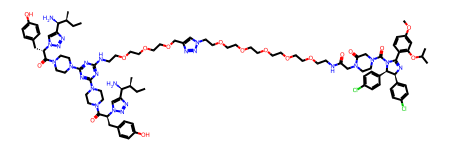

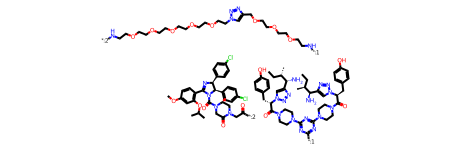

--------------------------------------------------------------------------------
PROTAC-DB
O=C1CCC(N2C(=O)c3cccc(NCCOCCOCCOCCOCCOCCOCCOCCOCCOCCNCCNc4nonc4/C(=N\O)Nc4ccc(F)c(Br)c4)c3C2=O)C(=O)N1


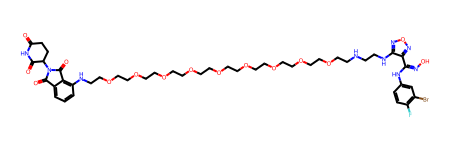

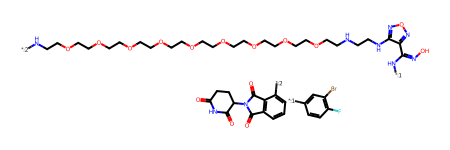

--------------------------------------------------------------------------------
TPDdb
Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)C2(F)CC2)C(C)(C)C)c(OCCCCCCCCCCCCCCCCN(C)CCOC23CC4(C)CC(C)(CC(Cn5ncc(-c6ccc(N7CCCc8c7nnc(Nc7nc9ccccc9s7)c8C)nc6C(=O)O)c5C)(C4)C2)C3)c1


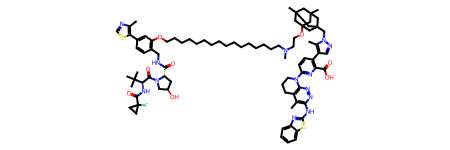

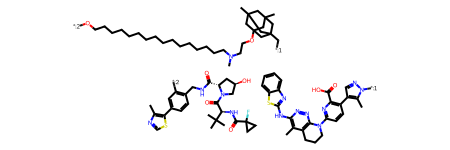

--------------------------------------------------------------------------------
PROTAC-DB
O=C(CCc1ccc2c(c1)[nH]c1ccncc12)NCCOCCOCCOCCOCCOCCOCCOCCOCCOCCOCCOCCNc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O


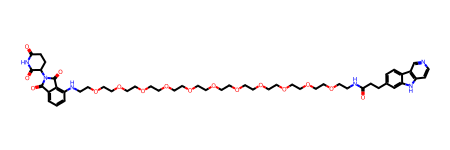

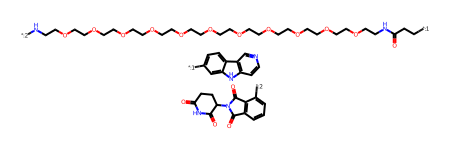

--------------------------------------------------------------------------------
TPDdb
Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@H](O)NC(=O)COCC(C)(COCCOCCOCCNC(=O)C[C@@H]2N=C(c3ccc(Cl)cc3)c3c(sc(C)c3C)-n3c(C)nnc32)COCCOCCOCCNC(=O)C[C@@H]2N=C(c3ccc(CI)cc3)c3c(sc(C)c3C)-n3c(C)nnc32)cc1


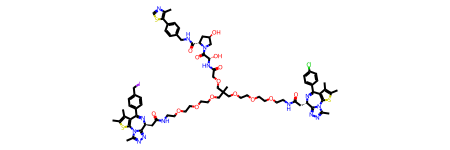

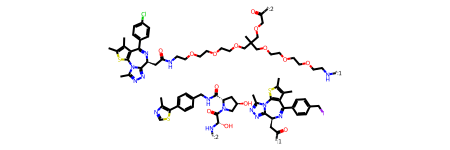

--------------------------------------------------------------------------------
TPDdb
Cc1cc(N(CCCCN(C)C(=O)CCCCCCCCCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)N[C@@H](C)c2ccc(-c3scnc3C)cc2)C(C)(C)C)c2ccc(-c3cnn(CC45CC6(C)CC(C)(C4)CC(OCCN(C)C)(C6)C5)c3C)c(C(=O)O)n2)nnc1Nc1nc2ccccc2s1


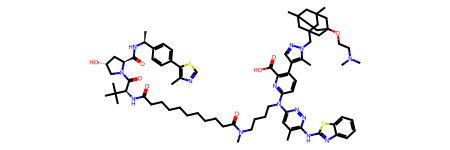

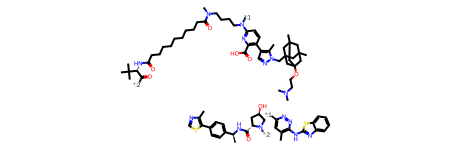

--------------------------------------------------------------------------------
PROTACpedia
Nc1nc2c(ncn2[C@H]2O[C@@H](COP(=O)(O)OP(=O)(O)NCCOCCOCCOCCOCCOCCOCCOCCC(=O)Nc3cccc4c3CN(C3CCC(=O)NC3=O)C4=O)[C@H](O)[C@@H]2O)c(=O)[nH]1


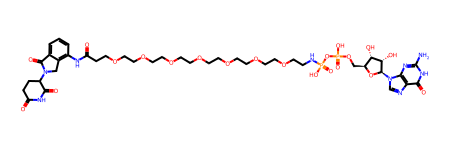

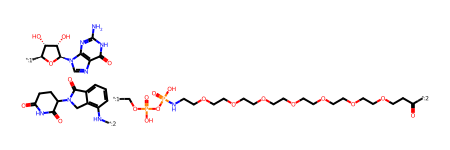

--------------------------------------------------------------------------------
TPDdb
COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCCCC(=O)NC(COCc1cn(CCCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)NCc2ccc(-c3scnc3C)cc2)C(C)(C)C)nn1)C(=O)NCC(=O)N1CCN(C(=O)c2cc(Cc3n[nH]c(=O)c4ccccc34)ccc2F)CC1


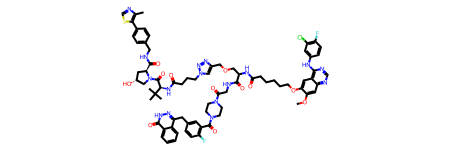

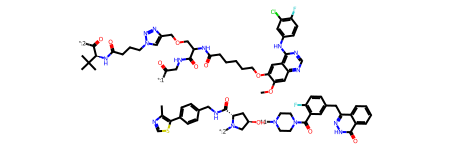

--------------------------------------------------------------------------------
TPDdb
Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)C2CCN(C(=O)CCCCCCCCCCCN(C)CCOC34CC5(C)CC(C)(CC(Cn6ncc(-c7ccc(N8CCCc9c8nnc(Nc8nc%10ccccc%10s8)c9C)nc7C(=O)O)c6C)(C5)C3)C4)CC2)C(C)(C)C)cc1


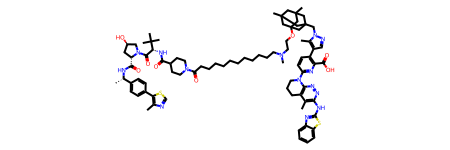

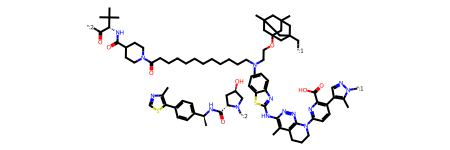

--------------------------------------------------------------------------------
PROTAC-DB
O=C(CCOCCOCCOCCOCCOCCOCCOCCOCCOCCC(=O)NCCCOc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O)NCCCOC(=O)NC(Nc1ncccn1)C(Cl)(Cl)Cl


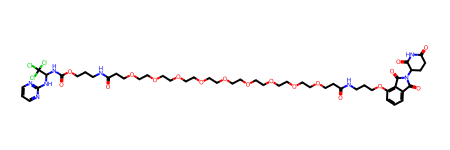

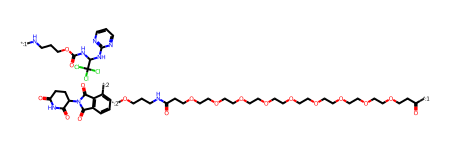

--------------------------------------------------------------------------------


In [80]:
for i, row in df[df['if_all_is_outlier']].sort_values('composite_outlier_rank', ascending=False).reset_index().iterrows():
    print(row['Database'])
    print(row['SMILES'])
    display(to_mol(row['SMILES']))
    display(to_mol(row['default_pred_n0']))
    print('-' * 80)
    if i > 20:
        break

TPDdb
Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)COCC(COCCOCCOCCNc2cc3c(cc2F)C(=O)N(C2CCC(=O)NC2=O)C3=O)(COCCOCCOCCOC(=O)C[C@@H]2N=C(c3ccc(Cl)cc3)c3c(sc(C)c3C)-n3c(C)nnc32)COCCOCCOCCOC(=O)C[C@@H]2N=C(c3ccc(Cl)cc3)c3c(sc(C)c3C)-n3c(C)nnc32)C(C)(C)C)cc1


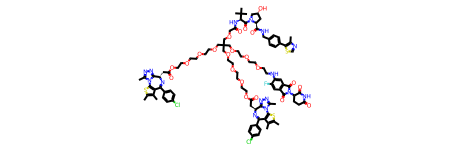

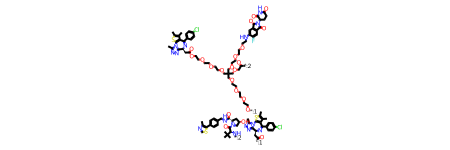

--------------------------------------------------------------------------------
TPDdb
COC(=O)C(CCC(=O)NCCCCCCCCNc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O)NC(=O)CC[C@H](NC(=O)CC[C@H](NC(=O)CC[C@H](NC(=O)CC[C@H](NC(=O)c1ccc(N(C)Cc2cnc3nc(N)nc(N)c3n2)cc1)C(=O)O)C(=O)OC)C(=O)OC)C(=O)OC


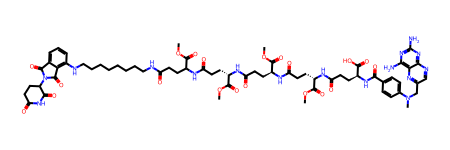

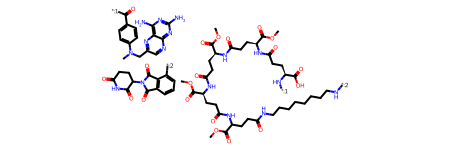

--------------------------------------------------------------------------------
TPDdb
Cc1cc(N(CCCCN(C)C(=O)CCCCCCCCCCCCSC(C)(C)[C@H](NC(=O)C2(F)CC2)C(=O)N2C[C@H](O)C[C@H]2C(=O)NCc2ccc(-c3scnc3C)cc2)c2ccc(-c3cnn(CC45CC6(C)CC(C)(C4)CC(OCCN(C)C)(C6)C5)c3C)c(C(=O)O)n2)nnc1Nc1nc2ccccc2s1


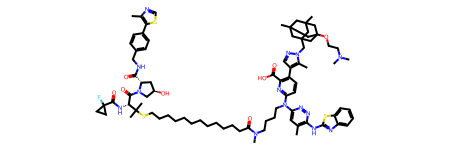

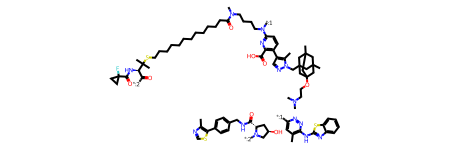

--------------------------------------------------------------------------------
TPDdb
Cc1cc(N(CCCCN(C)C(=O)CCCCCCCCCSC(C)(C)[C@H](NC(=O)C2(F)CC2)C(=O)N2C[C@H](O)C[C@H]2C(=O)NCc2ccc(-c3scnc3C)cc2)c2ccc(-c3cnn(CC45CC6(C)CC(C)(C4)CC(OCCN(C)C)(C6)C5)c3C)c(C(=O)O)n2)nnc1Nc1nc2ccccc2s1


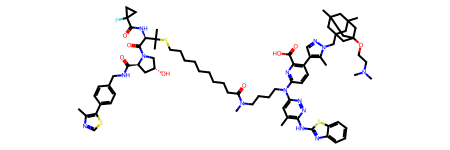

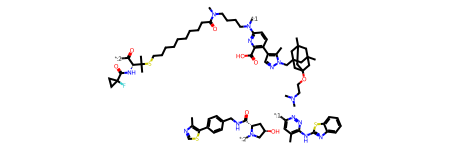

--------------------------------------------------------------------------------
TPDdb
CC1=C(C)C2=C(C1)n1c(C)nnc1[C@H](CC(=O)NCCOCCOCCOCCOCC(C)(COCCOCCOCCOCCNC(O)C[C@@H]1N=C(c3ccc(Cl)cc3)c3c(sc(C)c3C)-n3c(C)nnc31)COCC(=O)N[C@@H](C)C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1ccc(-c3scnc3C)cc1)N=C2c1ccc(Cl)cc1


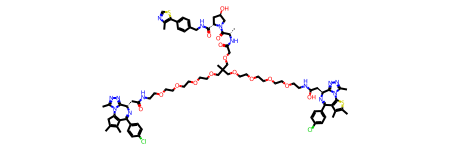

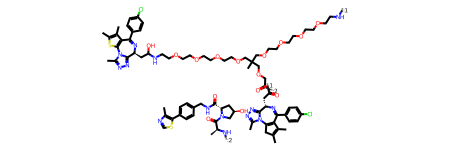

--------------------------------------------------------------------------------
TPDdb
Cc1cc(N(CCCCN(C)C(=O)CCCCCCCCCCCCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)N[C@@H](C)c2ccc(-c3scnc3C)cc2)C(C)(C)C)c2ccc(-c3cnn(CC45CC6(C)CC(C)(C4)CC(OCCN(C)C)(C6)C5)c3C)c(C(=O)O)n2)nnc1Nc1nc2ccccc2s1


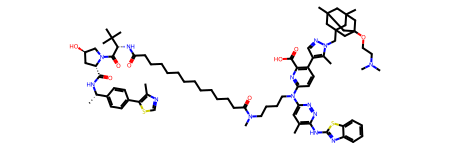

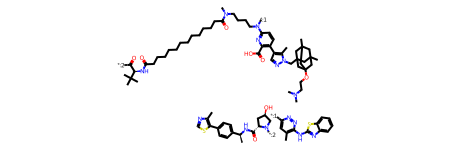

--------------------------------------------------------------------------------
TPDdb
COCCOCC(=O)NC(C(=O)N1C[C@@H](OC(=O)CCc2cn(CCCCCC(=O)OC(CCCOCCOCC(=O)N[C@H](C(=O)N3C[C@H](O)C[C@H]3C(=O)N[C@@H](C)c3ccc(-c4scnc4C)cc3)C(C)(C)C)CCOc3ccc(N4C(=S)N(c5ccc(C#N)c(C(F)(F)F)c5)C(=O)C4(C)C)cc3)nn2)C[C@H]1C(=O)N[C@@H](C)c1ccc(-c2scnc2C)cc1)C(C)(C)C


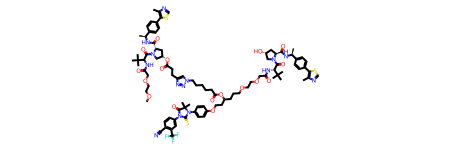

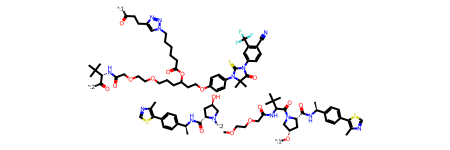

--------------------------------------------------------------------------------
TPDdb
Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@H](C)NC(=O)COCC(C)(COCCOCCOCCOCCN=NC(=O)C[C@@H]2N=C(c3ccc(Cl)cc3)c3c(sc(C)c3C)-n3c(C)nnc32)COCCOCCOCCOCCNC(=O)C[C@@H]2N=C(c3ccc(Cl)cc3)c3c(sc(C)c3C)-n3c(C)nnc32)cc1


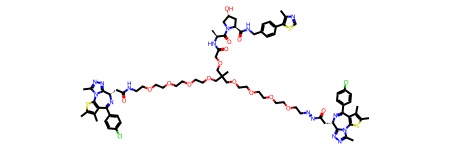

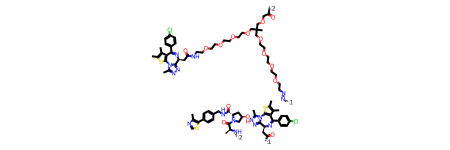

--------------------------------------------------------------------------------
TPDdb
Cc1cc(N(CCCCN(C)C(=O)CCCCCCCCCCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)N[C@@H](C)c2ccc(-c3scnc3C)cc2)C(C)(C)C)c2ccc(-c3cnn(CC45CC6(C)CC(C)(C4)CC(OCCN(C)C)(C6)C5)c3C)c(C(=O)N(C)C)n2)nnc1Nc1nc2ccccc2s1


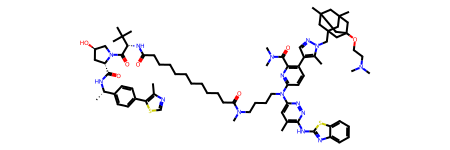

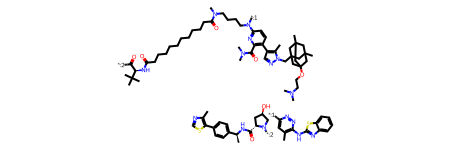

--------------------------------------------------------------------------------
PROTAC-DB
CC(C)(C)c1nc(-c2cccc(NS(=O)(=O)c3c(F)cccc3F)c2F)c(-c2ccnc(NCCCNC(=O)CCOCCOCCOCCOCCOCCNC(=O)CCOCCOCCOCCOCCOCCNc3cccc4c3C(=O)N(C3CCC(=O)NC3=O)C4=O)n2)s1


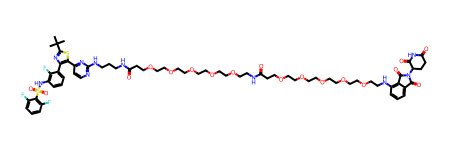

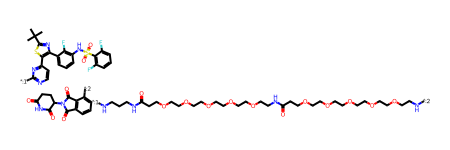

--------------------------------------------------------------------------------
TPDdb
Cc1cc(N(CCCCN(C)C(=O)CCCCCCCCCCCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)N[C@@H](C)c2ccc(-c3scnc3C)cc2)C(C)(C)C)c2ccc(-c3cnn(C[C@@]45C[C@@]6(C)C[C@@](O)(C4)C[C@](OCCN(C)C)(C6)C5)c3C)c(C(=O)O)n2)nnc1Nc1nc2ccccc2s1


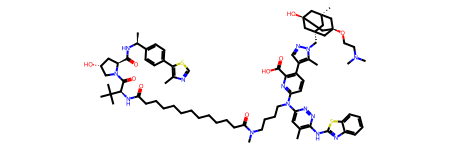

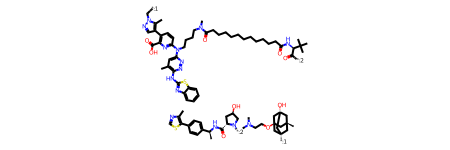

--------------------------------------------------------------------------------
TPDdb
Cc1cc(N(CCCCN(C)C(=O)CCCCCCCCCCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)N[C@@H](C)c2ccc(-c3scnc3C)cc2)C(C)(C)C)c2ccc(-c3cnn(CC45CC6(C)CC(C)(C4)CC(OCCN(C)C)(C6)C5)c3C)c(C(=O)O)n2)nnc1Nc1nc2ccccc2s1


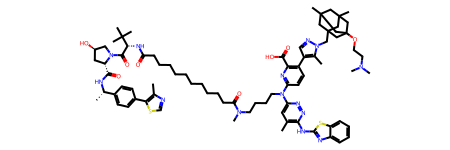

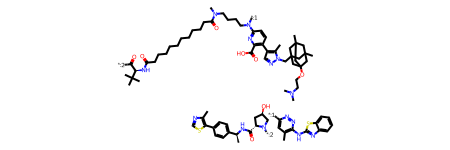

--------------------------------------------------------------------------------
PROTAC-DB; PROTACpedia
CC[C@H](C)[C@H](N)c1cn([C@@H](Cc2ccc(O)cc2)C(=O)N2CCN(c3nc(NCCOCCOCCOCc4cn(CCOCCOCCOCCOCCOCCNC(=O)CN5CCN(C(=O)N6C(c7ccc(OC)cc7OC(C)C)=N[C@@H](c7ccc(Cl)cc7)[C@H]6c6ccc(Cl)cc6)CC5=O)nn4)nc(N4CCN(C(=O)[C@H](Cc5ccc(O)cc5)n5cc([C@@H](N)[C@@H](C)CC)nn5)CC4)n3)CC2)nn1


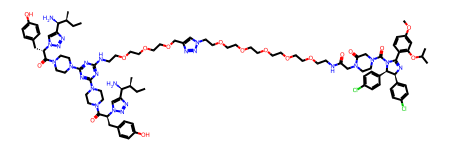

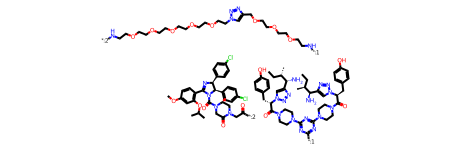

--------------------------------------------------------------------------------
PROTAC-DB
O=C1CCC(N2C(=O)c3cccc(NCCOCCOCCOCCOCCOCCOCCOCCOCCOCCNCCNc4nonc4/C(=N\O)Nc4ccc(F)c(Br)c4)c3C2=O)C(=O)N1


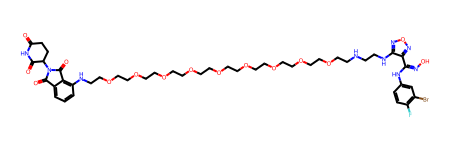

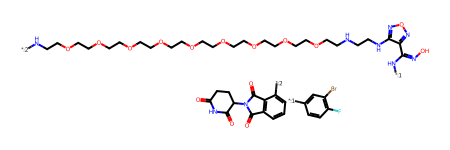

--------------------------------------------------------------------------------
TPDdb
Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)C2(F)CC2)C(C)(C)C)c(OCCCCCCCCCCCCCCCCN(C)CCOC23CC4(C)CC(C)(CC(Cn5ncc(-c6ccc(N7CCCc8c7nnc(Nc7nc9ccccc9s7)c8C)nc6C(=O)O)c5C)(C4)C2)C3)c1


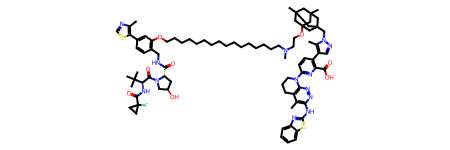

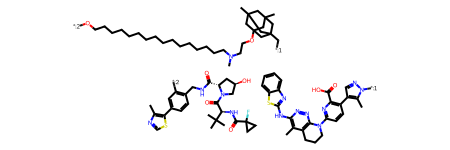

--------------------------------------------------------------------------------
PROTAC-DB
O=C(CCc1ccc2c(c1)[nH]c1ccncc12)NCCOCCOCCOCCOCCOCCOCCOCCOCCOCCOCCOCCNc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O


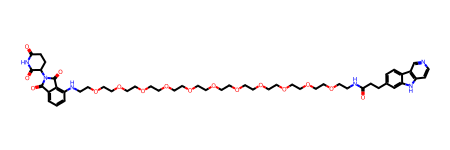

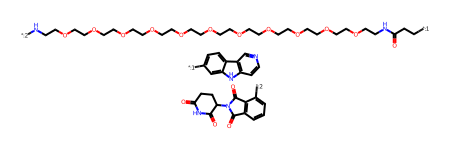

--------------------------------------------------------------------------------
TPDdb
Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@H](O)NC(=O)COCC(C)(COCCOCCOCCNC(=O)C[C@@H]2N=C(c3ccc(Cl)cc3)c3c(sc(C)c3C)-n3c(C)nnc32)COCCOCCOCCNC(=O)C[C@@H]2N=C(c3ccc(CI)cc3)c3c(sc(C)c3C)-n3c(C)nnc32)cc1


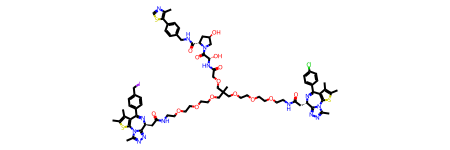

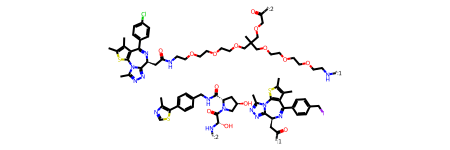

--------------------------------------------------------------------------------
TPDdb
Cc1cc(N(CCCCN(C)C(=O)CCCCCCCCCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)N[C@@H](C)c2ccc(-c3scnc3C)cc2)C(C)(C)C)c2ccc(-c3cnn(CC45CC6(C)CC(C)(C4)CC(OCCN(C)C)(C6)C5)c3C)c(C(=O)O)n2)nnc1Nc1nc2ccccc2s1


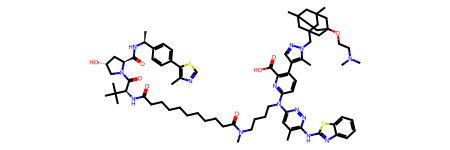

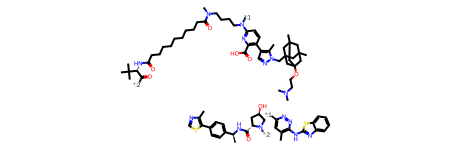

--------------------------------------------------------------------------------
PROTACpedia
Nc1nc2c(ncn2[C@H]2O[C@@H](COP(=O)(O)OP(=O)(O)NCCOCCOCCOCCOCCOCCOCCOCCC(=O)Nc3cccc4c3CN(C3CCC(=O)NC3=O)C4=O)[C@H](O)[C@@H]2O)c(=O)[nH]1


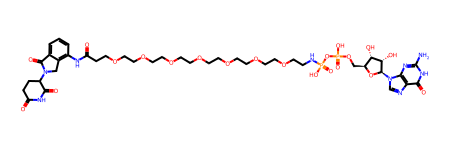

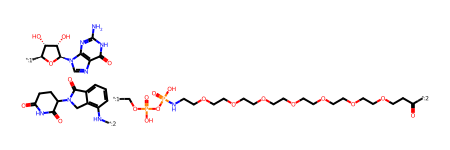

--------------------------------------------------------------------------------
TPDdb
COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCCCC(=O)NC(COCc1cn(CCCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)NCc2ccc(-c3scnc3C)cc2)C(C)(C)C)nn1)C(=O)NCC(=O)N1CCN(C(=O)c2cc(Cc3n[nH]c(=O)c4ccccc34)ccc2F)CC1


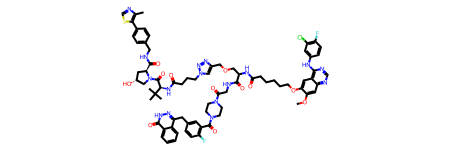

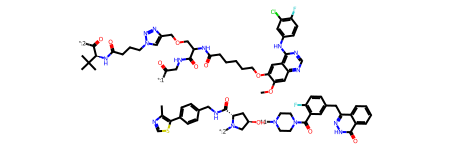

--------------------------------------------------------------------------------
TPDdb
Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)C2CCN(C(=O)CCCCCCCCCCCN(C)CCOC34CC5(C)CC(C)(CC(Cn6ncc(-c7ccc(N8CCCc9c8nnc(Nc8nc%10ccccc%10s8)c9C)nc7C(=O)O)c6C)(C5)C3)C4)CC2)C(C)(C)C)cc1


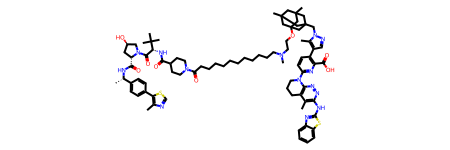

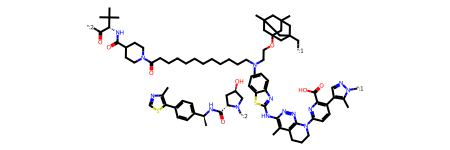

--------------------------------------------------------------------------------
PROTAC-DB
O=C(CCOCCOCCOCCOCCOCCOCCOCCOCCOCCC(=O)NCCCOc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O)NCCCOC(=O)NC(Nc1ncccn1)C(Cl)(Cl)Cl


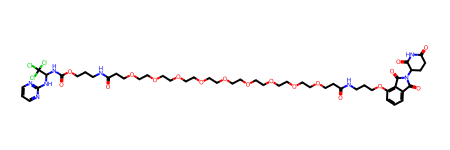

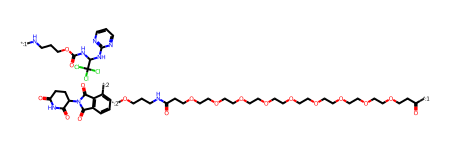

--------------------------------------------------------------------------------


In [81]:
for i, row in df.sort_values('composite_outlier_rank', ascending=False).reset_index().iterrows():
    print(row['Database'])
    print(row['SMILES'])
    display(to_mol(row['SMILES']))
    display(to_mol(row['default_pred_n0']))
    print('-' * 80)
    if i > 20:
        break

TPDdb
O=C1CCC(N2C(=O)c3cccc(OCCN4CCN(CCOc5ccc6cc5COC/C=C/COCc5cccc(c5)-c5ccnc(n5)N6)CC4)c3C2=O)C(=O)N1
0.8712115105594067


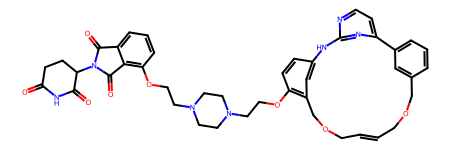

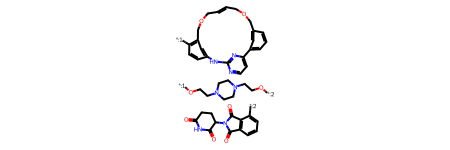

--------------------------------------------------------------------------------
TPDdb
O=C1CCC(N2C(=O)c3cccc(OCCOCCN4CCN(CCOc5ccc6cc5COC/C=C/COCc5cccc(c5)-c5ccnc(n5)N6)CC4)c3C2=O)C(=O)N1
0.8747339996775754


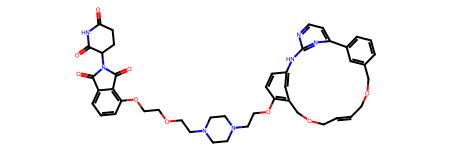

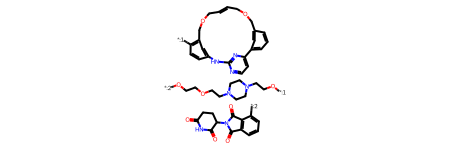

--------------------------------------------------------------------------------
TPDdb
O=C1CCC(N2C(=O)c3cccc(OCCOCCOCCN4CCN(CCOc5ccc6cc5COC/C=C/COCc5cccc(c5)-c5ccnc(n5)N6)CC4)c3C2=O)C(=O)N1
0.9079235853619216


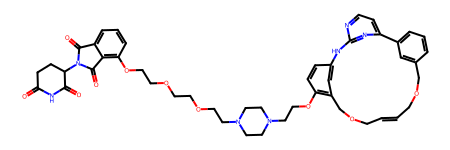

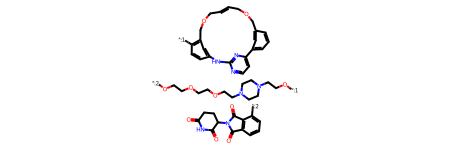

--------------------------------------------------------------------------------
TPDdb
COc1cc(N2CCC3(CC2)CN(CC2CCN(c4ccc5c(c4)C(=O)N(C4CCC(=O)NC4=O)C5=O)CC2)C3)c2cc1Nc1ncc(Br)c(n1)Nc1ccc(cc1N(C)S(C)(=O)=O)OCCCCOC2=O
0.9082298887635014


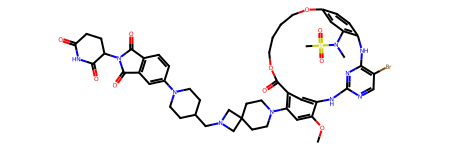

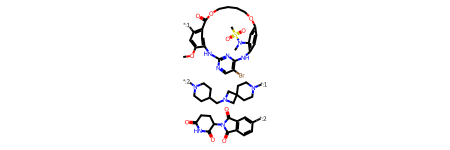

--------------------------------------------------------------------------------
TPDdb
COc1cc(N2CCC3(CC2)CN(CC2CCN(c4ccc5c(c4)C(=O)N(C4CCC(=O)NC4=O)C5=O)CC2)C3)c2cc1Nc1ncc(Br)c(n1)Nc1ccc(cc1N(C)S(C)(=O)=O)OCCCCn1cc-2cn1
0.9085442527809124


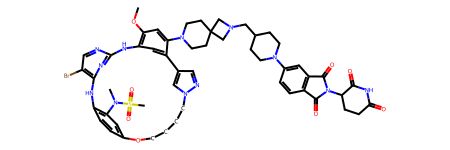

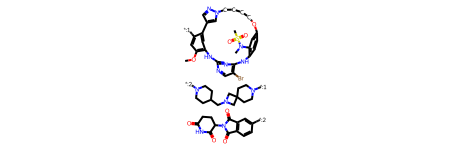

--------------------------------------------------------------------------------
TPDdb
COc1cc(N2CCC(N3CCN(CCc4ccc5c(C6CCC(=O)NC6=O)nn(C)c5c4)CC3)CC2)c2cc1Nc1ncc(Br)c(n1)Nc1ccc(cc1N(C)S(C)(=O)=O)OCCCCn1cc-2cn1
0.9173021118813477


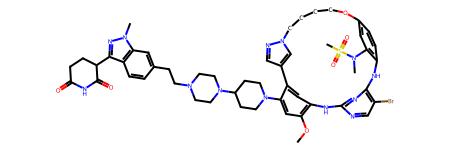

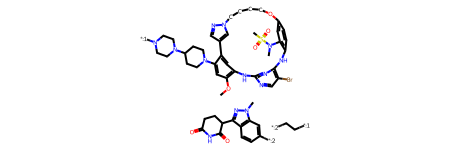

--------------------------------------------------------------------------------
TPDdb
COc1cc(N2CCC(CCN3CCN(c4ccc5c(c4)C(=O)N(C4CCC(=O)NC4=O)C5=O)CC3)CC2)c2cc1Nc1ncc(Br)c(n1)Nc1ccc(cc1N(C)S(C)(=O)=O)OCCCCn1cc-2cn1
0.9173343543446719


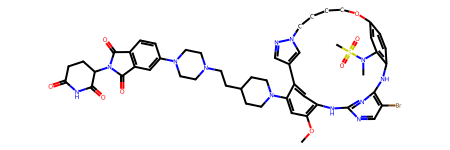

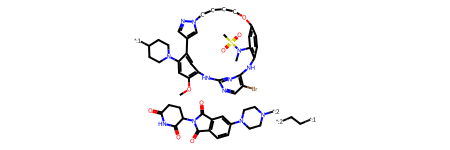

--------------------------------------------------------------------------------
TPDdb
COc1cc(N2CCC(N3CCN(CCc4cc(F)c(C5CCC(=O)NC5=O)c(F)c4)CC3)CC2)c2cc1Nc1ncc(Br)c(n1)Nc1ccc(cc1N(C)S(C)(=O)=O)OCCCCOC2=O
0.9185112042560052


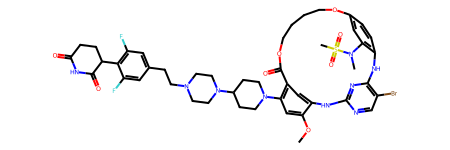

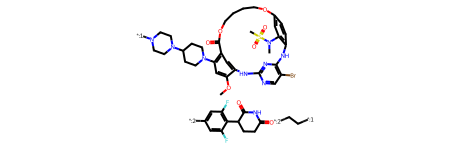

--------------------------------------------------------------------------------
TPDdb
COc1cc(N2CCC(N3CCN(CCc4cc(F)c(C5CCC(=O)NC5=O)c(F)c4)CC3)CC2)c2cc1Nc1ncc(Br)c(n1)Nc1ccc(cc1N(C)S(C)(=O)=O)OCCCCn1cc-2cn1
0.9187207802676124


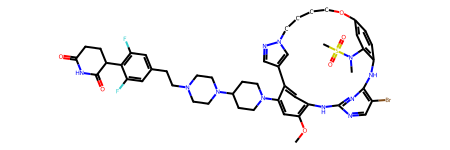

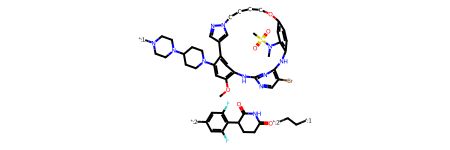

--------------------------------------------------------------------------------
TPDdb
COc1cc(N2CCC(CN3CCC4(CC3)CCN(c3ccc5c(c3)C(=O)N(C3CCC(=O)NC3=O)C5=O)CC4)CC2)c2cc1Nc1ncc(Br)c(n1)Nc1ccc(cc1N(C)S(C)(=O)=O)OCCCCOC2=O
0.921445268418507


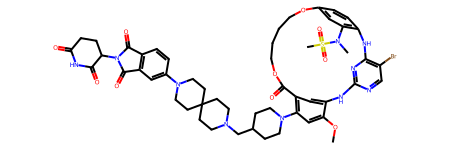

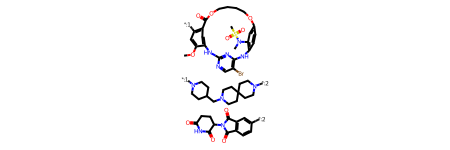

--------------------------------------------------------------------------------
TPDdb
CC(C)(C)c1cc(NC(=O)Cc2ccc(-c3nc4n5c(cnc(N)c35)/C=C/CCN(C(=O)C3CCN(c5ccc(C6CCC(=O)NC6=O)cc5F)CC3)CCC(=O)N[C@@H]3CCC[C@@H]4C3)cc2)no1
0.9294333387070772


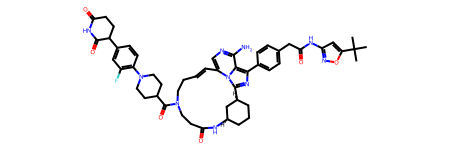

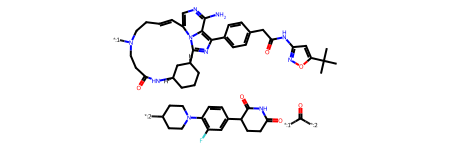

--------------------------------------------------------------------------------
TPDdb
COc1cc(N2CCC(N3CCN(C(=O)[C@H](C)Nc4cccc5c4C(=O)N(C4CCC(=O)NC4=O)C5=O)CC3)CC2)c2cc1Nc1ncc(Br)c(n1)Nc1ccc(cc1N(C)S(C)(=O)=O)OCCCCOC2=O
0.9332943736901498


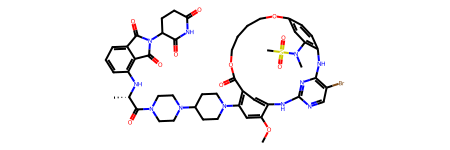

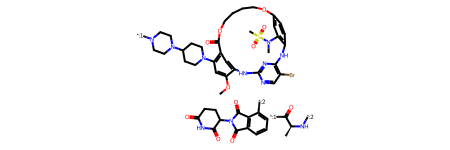

--------------------------------------------------------------------------------
TPDdb
CC(C)(C)c1cc(NC(=O)Cc2ccc(-c3nc4n5c(cnc(N)c35)/C=C/CCCN(CC3CN(c5ccc6c(c5)C(=O)N(C5CCC(=O)NC5=O)C6=O)C3)CC(=O)N[C@@H]3CCC[C@@H]4C3)cc2)no1
0.9535144285023376


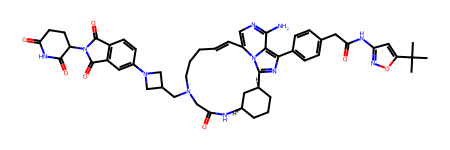

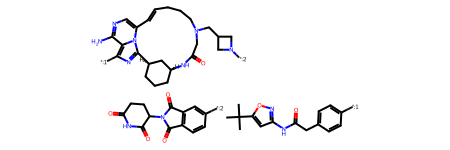

--------------------------------------------------------------------------------
TPDdb
CC(C)(C)c1cc(NC(=O)Cc2ccc(-c3nc4n5c(cnc(N)c35)/C=C/CCN(C[C@H]3CCN(c5ccc6c(c5)C(=O)N(C5CCC(=O)NC5=O)C6=O)C3)CCC(=O)N[C@@H]3CCC[C@@H]4C3)cc2)no1
0.95391745929389


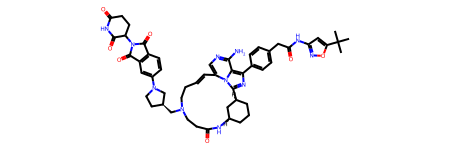

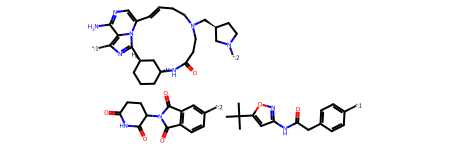

--------------------------------------------------------------------------------
TPDdb
CC(C)(C)c1cc(NC(=O)Cc2ccc(-c3nc4n5c(cnc(N)c35)/C=C/CCN(CC3CN(c5ccc6c(c5)C(=O)N(C5CCC(=O)NC5=O)C6=O)C3)CC(=O)N[C@@H]3CCC[C@@H]4C3)cc2)no1
0.9542076414638079


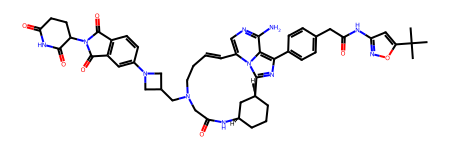

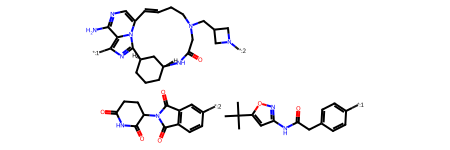

--------------------------------------------------------------------------------
TPDdb
COc1cc(N2CCC(N(C)C3CCN(c4ccc5c(c4)C(=O)N(C4CCC(=O)NC4=O)C5=O)CC3)CC2)c2cc1Nc1ncc(Br)c(n1)Nc1ccc(cc1N(C)S(C)(=O)=O)OCCCCn1cc-2cn1
0.9544494599387393


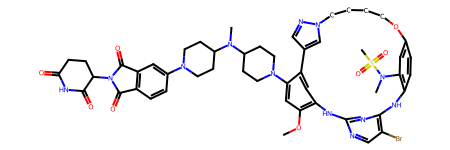

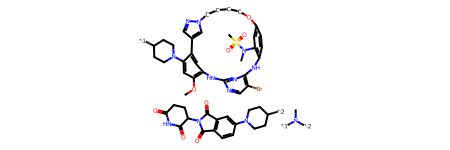

--------------------------------------------------------------------------------
TPDdb
CC(C)(C)c1cc(NC(=O)Cc2ccc(-c3nc4n5c(cnc(N)c35)/C=C/CCN(CC3CCN(c5ccc(C(=O)NC6CCC(=O)NC6=O)nc5)CC3)CCC(=O)N[C@@H]3CCC[C@@H]4C3)cc2)no1
0.9545784297920361


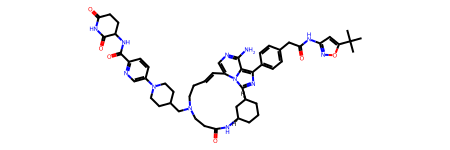

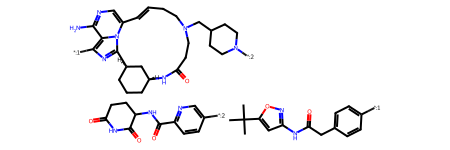

--------------------------------------------------------------------------------
TPDdb
Nc1ncc2c3c1c(-c1ccc(C(=O)Nc4cc(C(F)(F)F)ccn4)cc1)nn3[C@H]1C[C@H](C(=O)NCCCCC/C=C/2)N(CC2CCN(c3ccc(C4CCC(=O)NC4=O)cc3F)CC2)C1
0.9602772851845881


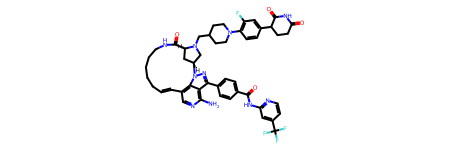

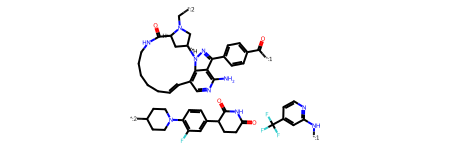

--------------------------------------------------------------------------------
TPDdb
COc1cc(N2CCC(CN3C[C@@H]4C[C@H]3CN4c3ccc4c(C5CCC(=O)NC5=O)nn(C)c4c3)CC2)c2cc1Nc1ncc(Br)c(n1)Nc1ccc(cc1N(C)S(C)(=O)=O)OCCCCn1cc-2cn1
0.970284539738836


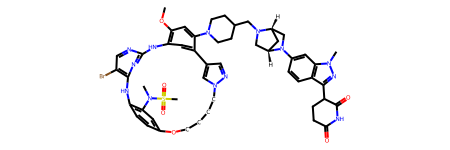

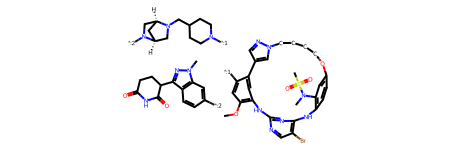

--------------------------------------------------------------------------------
TPDdb
COc1cc(N2CCC(CN3C[C@H]4C[C@@H]3CN4c3ccc4c(C5CCC(=O)NC5=O)nn(C)c4c3)CC2)c2cc1Nc1ncc(Br)c(n1)Nc1ccc(cc1N(C)S(C)(=O)=O)OCCCCn1cc-2cn1
0.970284539738836


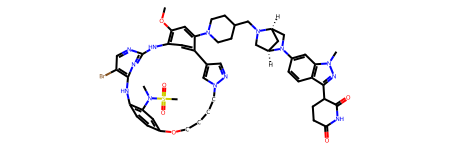

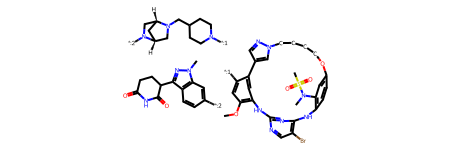

--------------------------------------------------------------------------------
PROTACpedia
CC[C@@H]1NC(=O)[C@H]([C@H](O)[C@H](C)C/C=C/CCCCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)N[C@@H](C)c2ccc(-c3scnc3C)cc2)C(C)(C)C)N(C)C(=O)[C@H](C(C)C)N(C)C(=O)[C@H](CC(C)C)N(C)C(=O)[C@H](CC(C)C)N(C)C(=O)[C@@H](C)NC(=O)[C@H](C)NC(=O)[C@H](CC(C)C)N(C)C(=O)[C@H](C(C)C)NC(=O)[C@H](CC(C)C)N(C)C(=O)CN(C)C1=O
0.9704941157504432


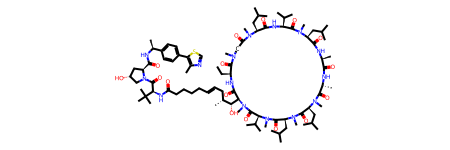

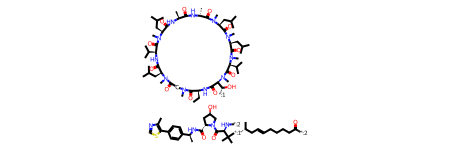

--------------------------------------------------------------------------------
TPDdb
Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)C(NC(=O)CN2CCOCCOCCN(c3ccc(C(=O)NC4C(C)(C)C(Oc5ccc(C#N)c(Cl)c5)C4(C)C)cc3)CCOCCOCC2)C(C)(C)C)cc1
0.9736377559245526


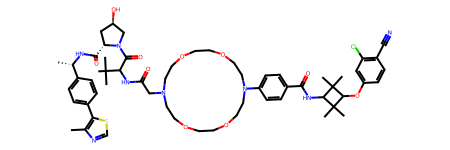

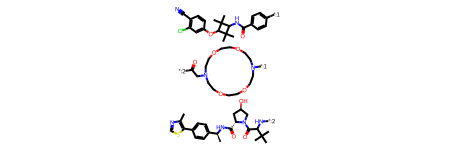

--------------------------------------------------------------------------------


In [82]:
for i, row in df[(~df['is_good_quality']) & (df['protac_max_ring_size'] > 12)].sort_values('composite_outlier_rank', ascending=True).reset_index().iterrows():
    print(row['Database'])
    print(row['SMILES'])
    print(row['composite_outlier_rank'])
    display(to_mol(row['SMILES']))
    display(to_mol(row['default_pred_n0']))
    print('-' * 80)
    if i > 20:
        break

TPDdb
O=C1CCC(N2C(=O)c3cc4c(cc3C2=O)CN(CC2(F)CCN(CC3CN(c5ccc([C@@H]6c7ccc(O)cc7CC[C@@H]6c6ccccc6)cc5)C3)CC2)C4)C(=O)N1
0.29505078187973566


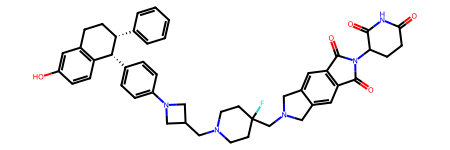

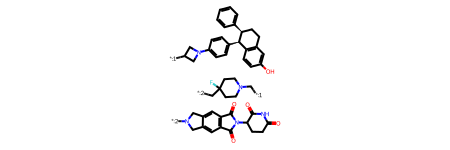

--------------------------------------------------------------------------------
TPDdb
O=C1CCC(N2C(=O)c3cc4c(cc3C2=O)CN(CC2(F)CCN(CC3CCN(c5ccc([C@@H]6c7ccc(O)cc7CC[C@@H]6c6ccccc6)cc5)CC3)CC2)C4)C(=O)N1
0.3364662260196679


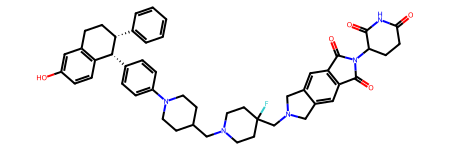

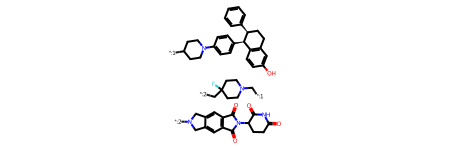

--------------------------------------------------------------------------------
TPDdb
COc1cc(N2CCN(C(=O)N3CCC(c4ccc(NC5CCC(=O)NC5=O)cc4)CC3)CC2)ccc1Nc1ncc(Cl)c(Nc2ccccc2C(C)=O)n1
0.35626712880864103


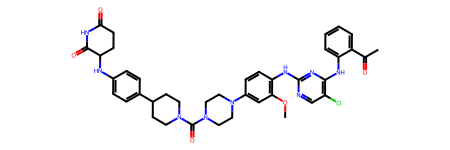

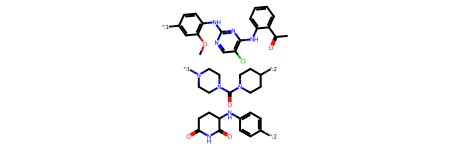

--------------------------------------------------------------------------------
TPDdb
CC1(C)[C@H](Oc2ccc(C#N)c(Cl)c2)C(C)(C)[C@H]1N1Cc2nc(C#CC3CCN(CC4CN(c5ccc6c(c5)C(=O)N(C5CCC(=O)NC5=O)C6=O)C4)CC3)ccc2C1=O
0.38042882476221185


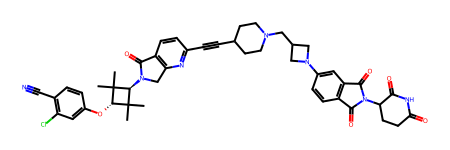

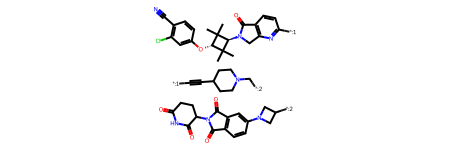

--------------------------------------------------------------------------------
TPDdb
CC1(C)[C@H](Oc2ccc(C#N)c(Cl)c2)C(C)(C)[C@H]1N1Cc2nc(C#CC3CCN(CC4CN(c5cc6c(cc5F)C(=O)N(C5CCC(=O)NC5=O)C6=O)C4)CC3)ccc2C1=O
0.3836974044817024


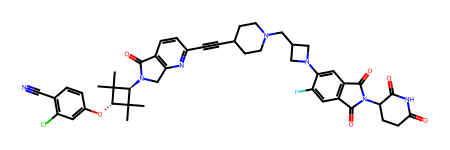

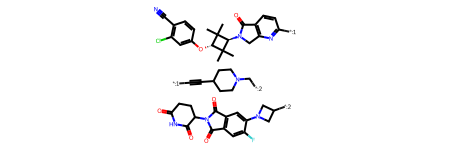

--------------------------------------------------------------------------------
TPDdb
CC1(C)[C@H](Oc2ccc(C#N)c(Cl)c2)C(C)(C)[C@H]1N1Cc2nc(C#CC3CCN(CC4CCN(c5ccc6c(c5)C(=O)N(C5CCC(=O)NC5=O)C6=O)CC4)CC3)ccc2C1=O
0.41638320167660814


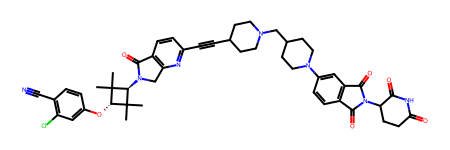

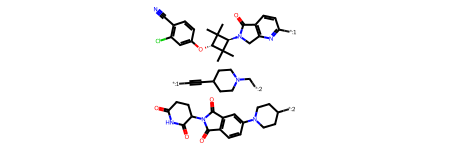

--------------------------------------------------------------------------------
TPDdb
CC1(C)[C@H](NC(=O)c2ccc(N3CCC(N4Cc5cc6c(cc5C4)C(=O)N(C4CCC(=O)NC4=O)C6=O)CC3)cc2F)C(C)(C)[C@H]1Oc1ccc(C#N)c(Cl)c1
0.4306021280025794


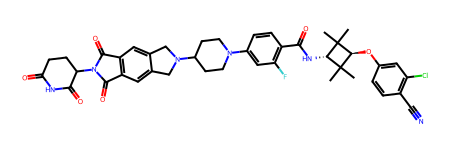

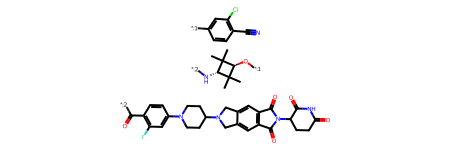

--------------------------------------------------------------------------------
TPDdb
CC1(C)[C@H](NC(=O)c2ccc(N3CCC(N4Cc5cc6c(cc5C4)C(=O)N(C4CCC(=O)NC4=O)C6=O)CC3)c(F)c2)C(C)(C)[C@H]1Oc1ccc(C#N)c(Cl)c1
0.4320288570046752


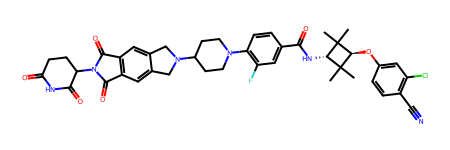

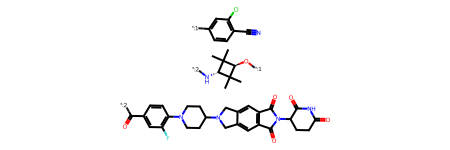

--------------------------------------------------------------------------------
TPDdb
CC1(C)[C@H](NC(=O)c2ccc(N3CCC(N4CCc5cc6c(cc5C4)C(=O)N(C4CCC(=O)NC4=O)C6=O)CC3)cc2)C(C)(C)[C@H]1Oc1ccc(C#N)c(Cl)c1
0.4336087377075609


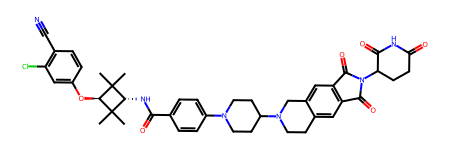

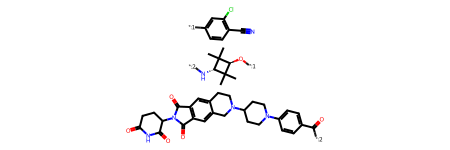

--------------------------------------------------------------------------------
TPDdb
CC1(C)[C@H](NC(=O)c2ccc(N3CCC(N4Cc5cc6c(cc5C4)C(=O)N(C4CCC(=O)NC4=O)C6=O)CC3)cc2)C(C)(C)[C@H]1Oc1ccc(C#N)c(Cl)c1
0.4337538287925198


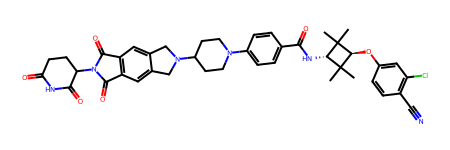

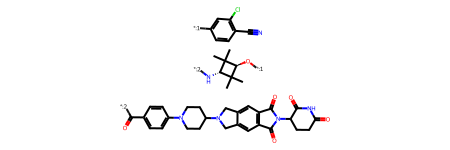

--------------------------------------------------------------------------------
TPDdb
CC1(C)[C@H](NC(=O)c2ccc(N3CCN(C4Cc5cc6c(cc5C4)C(=O)N(C4CCC(=O)NC4=O)C6=O)CC3)cc2)C(C)(C)[C@H]1Oc1ccc(C#N)c(Cl)c1
0.4397589875866516


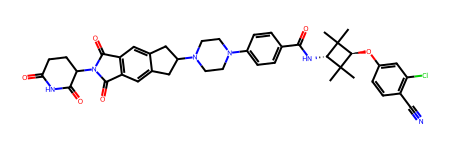

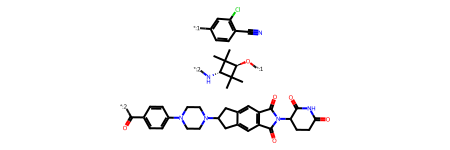

--------------------------------------------------------------------------------
TPDdb
CC1(C)[C@H](NC(=O)c2ccc(N3CCC(N4Cc5cc6c(cc5C4)C(=O)N(C4CCC(=O)NC4=O)C6)CC3)cc2)C(C)(C)[C@H]1Oc1ccc(C#N)c(Cl)c1
0.4436119619538933


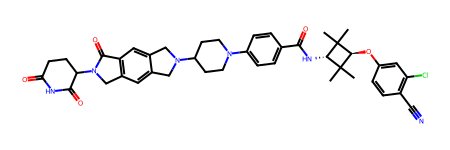

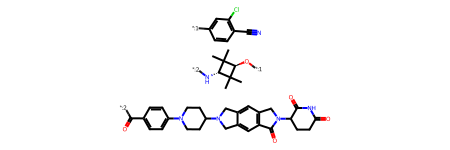

--------------------------------------------------------------------------------
TPDdb
CC1(C)[C@H](NC(=O)c2ccc(N3CCC(n4cc5cc6c(cc5c4)C(=O)N(C4CCC(=O)NC4=O)C6=O)CC3)cc2)C(C)(C)[C@H]1Oc1ccc(C#N)c(Cl)c1
0.44396662905045947


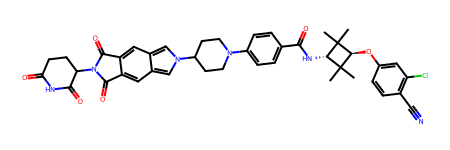

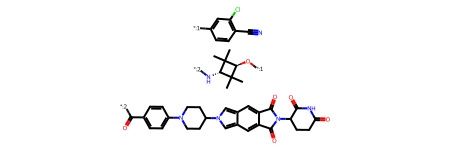

--------------------------------------------------------------------------------
TPDdb
CC1(C)[C@H](NC(=O)c2ccc(N3CCC(N4Cc5cc6c(cc5C4)C(=O)N(C4CCC(=O)NC4=O)C6=O)CC3)cc2)C(C)(C)[C@H]1Nc1ccc(C#N)c(Cl)c1
0.445030630340158


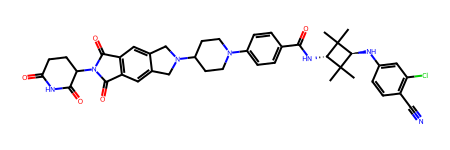

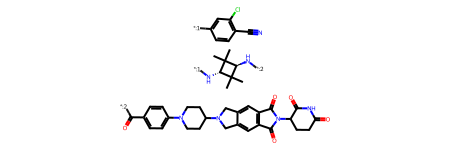

--------------------------------------------------------------------------------
TPDdb
CC1(C)[C@H](NC(=O)c2ccc(N3CCC(N4Cc5cc6c(cc5C4)C(=O)N(C4CCC(=O)NC4=O)C6=O)CC3)nc2)C(C)(C)[C@H]1Oc1ccc(C#N)c(Cl)c1
0.44582057069160086


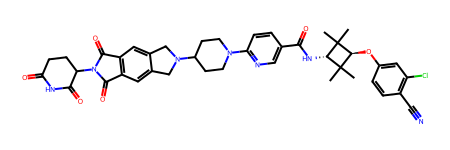

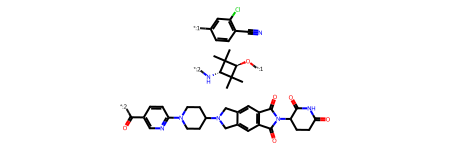

--------------------------------------------------------------------------------
TPDdb
CC1(C)[C@H](NC(=O)c2ccc(N3CCC(N4Cc5cc6c(cc5C4)C(=O)N(C4CCC(=O)NC4=O)C6=O)CC3)cn2)C(C)(C)[C@H]1Oc1ccc(C#N)c(Cl)c1
0.4464573593422537


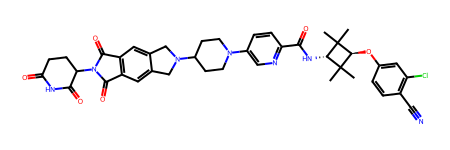

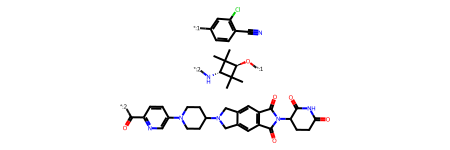

--------------------------------------------------------------------------------
PROTAC-DB
CC1(C)[C@H](NC(=O)c2ccc(N3CCN(C4CN(c5ccc6c(c5)C(=O)N(C5CCC(=O)NC5=O)C6=O)C4)CC3)cc2)C(C)(C)[C@H]1Oc1ccc(C#N)c(Cl)c1
0.4467475415121715


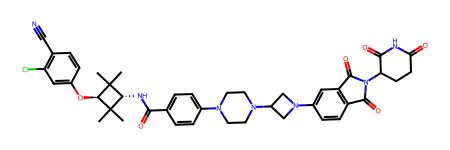

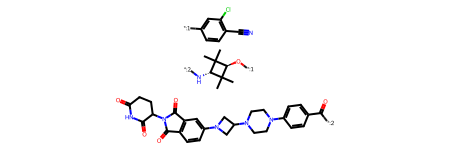

--------------------------------------------------------------------------------
TPDdb
CC1(C)[C@H](NC(=O)c2ccc(N3CCC(N4Cc5cc6c(cc5C4)C(=O)N(C4CCC(=O)NC4=O)C6=O)CC3)nn2)C(C)(C)[C@H]1Oc1ccc(C#N)c(Cl)c1
0.46365065290988233


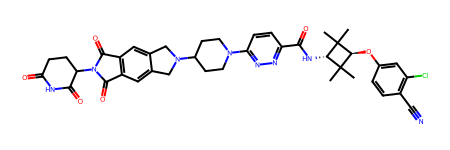

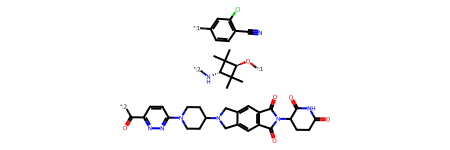

--------------------------------------------------------------------------------
TPDdb
CC1(C)[C@H](NC(=O)c2cnc(N3CCC(N4Cc5cc6c(cc5C4)C(=O)N(C4CCC(=O)NC4=O)C6=O)CC3)nc2)C(C)(C)[C@H]1Oc1ccc(C#N)c(Cl)c1
0.4650048363694987


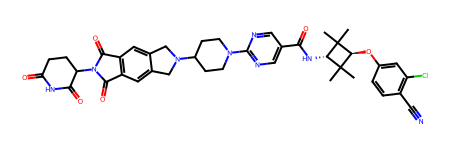

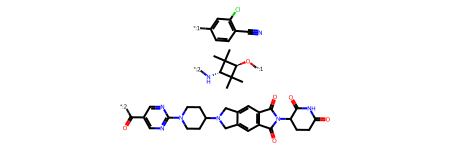

--------------------------------------------------------------------------------
TPDdb
Cc1c(-c2ccc(C#N)c(Cl)c2)nn(Cc2ccc(C#CC3CCN(CC4CCN(c5ccc6c(c5)C(=O)N(C5CCC(=O)NC5=O)C6=O)CC4)CC3)cc2)c1C
0.4834596163146864


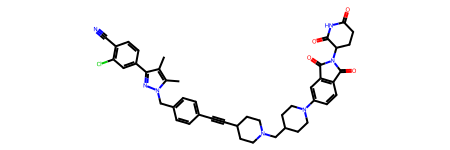

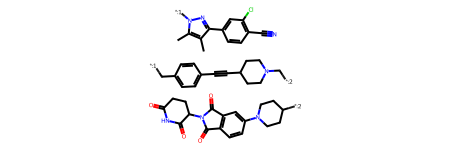

--------------------------------------------------------------------------------
TPDdb
N#Cc1ccc(O[C@H]2CC[C@H](N3Cc4cc(C#C[C@H]5CC[C@H](CN6CCc7cc8c(cc7C6)C(=O)N(C6CCC(=O)NC6=O)C8=O)CC5)ccc4C3=O)CC2)cc1Cl
0.48908995647267456


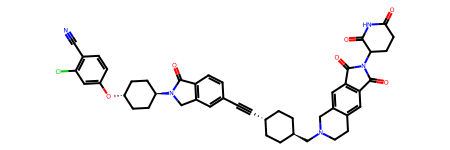

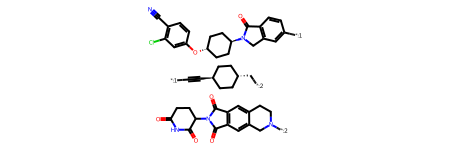

--------------------------------------------------------------------------------
TPDdb
N#Cc1ccc(O[C@H]2CC[C@H](N3Cc4cc(C#C[C@H]5CC[C@H](CN6Cc7cc8c(cc7C6)C(=O)N(C6CCC(=O)NC6=O)C8=O)CC5)ccc4C3=O)CC2)cc1Cl
0.495691600838304


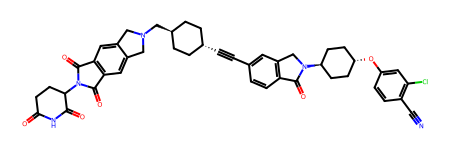

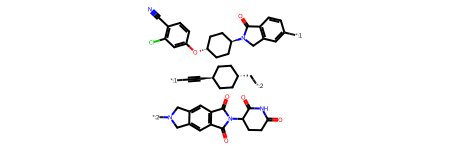

--------------------------------------------------------------------------------


In [83]:
for i, row in df[(df['is_good_quality']) & (df['linker_num_rotatable_bonds'].fillna(-1) == 0) & (df['linker_heavy_atoms'].fillna(0) > 8)].sort_values('composite_outlier_rank', ascending=True).reset_index().iterrows():
    print(row['Database'])
    print(row['SMILES'])
    print(row['composite_outlier_rank'])
    display(to_mol(row['SMILES']))
    display(to_mol(row['default_pred_n0']))
    print('-' * 80)
    if i > 20:
        break

### Using this

- `df['is_good_quality']` is the recommended filter — molecules in the bottom 5% by `composite_outlier_rank` (blending the rule-based score with all four IsolationForest scores) are treated as suspect and excluded.
- `df['composite_outlier_rank']` gives a continuous ranking if a harder or softer cutoff than the 95th percentile is wanted.
- The `linker_only` IsolationForest and the linker-weighted rule-based score are the two signals worth trusting most in isolation, per the assumption that the linker is the strongest single tell for "is this really a PROTAC."
- These are *unsupervised/heuristic* — spot-check `df.sort_values('composite_outlier_rank', ascending=False).head(50)` against the actual SMILES/structures before using this to hard-filter a training set.